# Compare Results — Multi-Objective CVRP

Analysis of NSGA-II, SPEA2, and Pareto ACO on the bi-objective CVRP benchmark instances. Two representations are evaluated: giant tour and cluster first. Metrics: Hypervolume (HV), Spacing (SP), Generational Distance (GD), Pareto front size (PF).

## 1. Setup & Load

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from cvrp.experiment.experiment_loader import ExperimentLoader
from cvrp.experiment.visualization import (
    plot_instance,
    plot_routes,
    plot_pareto_fronts_overlay,
    plot_metric_boxplots,
    plot_parameter_heatmap,
    plot_fitness_convergence,
    plot_chromosome_convergence,
    plot_diversity,
    plot_critical_difference,
)
from cvrp.metrics.statistical_tests import wilcoxon_test, friedman_shaffer_test
from cvrp.problem.parser import parse_vrp_file
from cvrp.problem.decoders import GiantTourDecoder, ClusterFirstDecoder
from cvrp.problem.fitness import evaluate

loader = ExperimentLoader("../experiments/")

algorithms = loader.algorithms()
representations = loader.representations()
instances = loader.instances()

with open("../experiments/grid_search_results.json") as f:
    grid_results = json.load(f)
with open("../experiments/best_hyperparams.json") as f:
    best_hyperparams = json.load(f)

# Representative instance for sections that need a single example
# (Pareto overlay, best routes, convergence plots). Chosen as a
# mid-sized instance present in the dataset.
REPRESENTATIVE_INSTANCE = "X-n200-k36"

# Metric direction (for Friedman + Wilcoxon interpretation).
MAXIMIZE = {"hv": True, "sp": False, "gd": False, "pf": True}

ALPHA = 0.05

print(f"Algorithms:      {algorithms}")
print(f"Representations: {representations}")
print(f"Instances ({len(instances)}): {instances}")
print(f"\nRepresentative instance for single-example sections: {REPRESENTATIVE_INSTANCE}")
print(f"Total rows: {len(loader.data)}")
print(
    f"Runs per (algo, rep, inst): "
    f"{loader.data.groupby(['algorithm', 'representation', 'instance'])['run'].nunique().min()}"
)

Algorithms:      ['nsga2', 'paco', 'spea2']
Representations: ['cluster_first', 'giant_tour']
Instances (12): ['X-n101-k25', 'X-n125-k30', 'X-n148-k46', 'X-n176-k26', 'X-n200-k36', 'X-n242-k48', 'X-n303-k21', 'X-n351-k40', 'X-n420-k130', 'X-n459-k26', 'X-n536-k96', 'X-n627-k43']

Representative instance for single-example sections: X-n200-k36
Total rows: 34071
Runs per (algo, rep, inst): 31


## 2. Summary tables — mean ± std per metric

For each metric (HV, SP, GD, PF), we compute the mean ± std across 31 runs for every (algorithm, representation, instance) combination. Two tables per metric: one per representation. Higher HV / PF is better; lower SP / GD is better.

In [2]:
def summary_table(metric: str, representation: str) -> pd.DataFrame:
    """Build a (algorithm × instance) table of 'mean ± std' for a metric."""
    rows = {}
    for algo in algorithms:
        row = {}
        for inst in instances:
            values = loader.compute_metric_series(algo, representation, inst, metric)
            row[inst] = f"{np.mean(values):.3g} ± {np.std(values):.2g}"
        rows[algo] = row
    return pd.DataFrame(rows).T

for metric in ["hv", "sp", "gd", "pf"]:
    for rep in representations:
        print(f"\n=== {metric.upper()} — {rep} ===")
        display(summary_table(metric, rep))


=== HV — cluster_first ===


,X-n101-k25,X-n125-k30,X-n148-k46,X-n176-k26,X-n200-k36,X-n242-k48,X-n303-k21,X-n351-k40,X-n420-k130,X-n459-k26,X-n536-k96,X-n627-k43
nsga2,6.89e+06 ± 1.2e+06,1.12e+07 ± 1.3e+06,1.03e+05 ± 1.9e+04,7.2e+06 ± 9.9e+05,4.96e+06 ± 1.8e+06,1.67e+05 ± 3.1e+04,3.51e+06 ± 8.4e+05,5.89e+06 ± 1.3e+06,3.42e+05 ± 3.9e+04,7.28e+06 ± 3.1e+06,4.46e+07 ± 9.8e+06,2.5e+05 ± 5.7e+04
paco,2.83e+06 ± 1.3e+06,4.29e+06 ± 1.9e+06,4.6e+04 ± 2.2e+04,1.43e+06 ± 8.4e+05,6.85e+06 ± 3.5e+06,1.26e+05 ± 5.2e+04,5.55e+06 ± 1.8e+06,8.49e+06 ± 3.9e+06,2.13e+05 ± 1e+05,2.11e+07 ± 6.8e+06,3.92e+07 ± 1.8e+07,4.9e+05 ± 1.5e+05
spea2,6.65e+06 ± 1.1e+06,1.04e+07 ± 1.4e+06,9.97e+04 ± 1.7e+04,7.47e+06 ± 7.9e+05,3.73e+06 ± 1.7e+06,1.44e+05 ± 2.1e+04,3.3e+06 ± 1.2e+06,4.49e+06 ± 1.6e+06,3.18e+05 ± 3.9e+04,4.95e+06 ± 2.3e+06,3.96e+07 ± 7.4e+06,2.06e+05 ± 7.1e+04



=== HV — giant_tour ===


,X-n101-k25,X-n125-k30,X-n148-k46,X-n176-k26,X-n200-k36,X-n242-k48,X-n303-k21,X-n351-k40,X-n420-k130,X-n459-k26,X-n536-k96,X-n627-k43
nsga2,5.2e+05 ± 4.8e+04,5.14e+05 ± 6.1e+04,3.85e+04 ± 4.4e+03,4.9e+05 ± 6e+04,1.85e+06 ± 2e+05,1.23e+05 ± 1.2e+04,6.69e+06 ± 3.7e+05,2.16e+06 ± 1.4e+05,6.4e+04 ± 7.2e+03,8.65e+06 ± 5.1e+05,2.01e+06 ± 1.5e+05,1.26e+06 ± 8.9e+04
paco,6.47e+05 ± 2.9e+04,5.82e+05 ± 2.8e+04,5.26e+04 ± 4.4e+03,6.65e+05 ± 4e+04,3.21e+06 ± 5.8e+04,2.32e+05 ± 9.2e+03,1.76e+07 ± 1e+05,4.99e+06 ± 6.7e+04,1.07e+05 ± 7.2e+03,2.46e+07 ± 2.3e+05,4.95e+06 ± 1.3e+05,4.07e+06 ± 2e+04
spea2,5.33e+05 ± 4.2e+04,5.6e+05 ± 4.6e+04,3.99e+04 ± 3.3e+03,4.79e+05 ± 5e+04,2.03e+06 ± 1.7e+05,1.26e+05 ± 1e+04,6.96e+06 ± 4.3e+05,2.15e+06 ± 1.2e+05,6.54e+04 ± 8.4e+03,8.68e+06 ± 4.4e+05,2.11e+06 ± 1.8e+05,1.23e+06 ± 9.5e+04



=== SP — cluster_first ===


...

,X-n101-k25,X-n125-k30,X-n148-k46,X-n176-k26,X-n200-k36,X-n242-k48,X-n303-k21,X-n351-k40,X-n420-k130,X-n459-k26,X-n536-k96,X-n627-k43
nsga2,962 ± 7.6e+02,1.04e+03 ± 6.4e+02,762 ± 9.1e+02,1.06e+03 ± 1.2e+03,5.46e+03 ± 4.2e+03,1.28e+03 ± 1.4e+03,3.71e+03 ± 2.9e+03,2e+03 ± 2.6e+03,1.63e+03 ± 1.9e+03,3.09e+03 ± 2.4e+03,5.21e+03 ± 2.3e+03,4.46e+03 ± 3.5e+03
paco,600 ± 5.9e+02,436 ± 3.6e+02,366 ± 3.6e+02,307 ± 1.8e+02,608 ± 6.7e+02,738 ± 1.1e+03,751 ± 9e+02,989 ± 1e+03,449 ± 3.5e+02,1.8e+03 ± 1.8e+03,909 ± 1.2e+03,993 ± 7.1e+02
spea2,905 ± 5.2e+02,846 ± 6.7e+02,472 ± 6e+02,1.01e+03 ± 1.2e+03,3.89e+03 ± 3.7e+03,1.41e+03 ± 1.5e+03,2.34e+03 ± 3.2e+03,1.95e+03 ± 1.9e+03,1.96e+03 ± 1.8e+03,2.61e+03 ± 3e+03,4.8e+03 ± 2.7e+03,4.33e+03 ± 2.9e+03



=== PF — cluster_first ===


,X-n101-k25,X-n125-k30,X-n148-k46,X-n176-k26,X-n200-k36,X-n242-k48,X-n303-k21,X-n351-k40,X-n420-k130,X-n459-k26,X-n536-k96,X-n627-k43
nsga2,1.55 ± 0.61,1.55 ± 0.84,2.42 ± 1.2,1.68 ± 1,1.58 ± 0.79,1.68 ± 0.89,2.1 ± 1,1.65 ± 0.65,2.65 ± 1.2,1.77 ± 1.1,1.97 ± 1.1,1.9 ± 1
paco,64.2 ± 47,40.6 ± 48,40 ± 48,52.4 ± 49,59.8 ± 47,44.5 ± 48,59.2 ± 48,38.6 ± 46,48.8 ± 48,45.6 ± 47,2.16 ± 1.8,48.4 ± 48
spea2,1.45 ± 0.71,1.68 ± 0.82,2.06 ± 1.2,1.94 ± 1.2,1.74 ± 1.1,2.19 ± 1.3,1.45 ± 0.61,1.77 ± 0.75,2.55 ± 1.1,1.48 ± 0.71,1.97 ± 1,2.16 ± 0.95



=== PF — giant_tour ===


,X-n101-k25,X-n125-k30,X-n148-k46,X-n176-k26,X-n200-k36,X-n242-k48,X-n303-k21,X-n351-k40,X-n420-k130,X-n459-k26,X-n536-k96,X-n627-k43
nsga2,20.3 ± 7.3,19.3 ± 8.3,14.5 ± 5,22.5 ± 6.4,19 ± 5.3,12.3 ± 4.3,17.6 ± 5.9,17.9 ± 5.7,18.5 ± 6.9,19.5 ± 5.5,19.3 ± 5.6,13.5 ± 3.5
paco,8.16 ± 17,5.45 ± 2.2,8.06 ± 8.3,9.23 ± 3.6,7.45 ± 3.8,5.32 ± 1.8,8.29 ± 2.6,6.32 ± 2.4,4.58 ± 2,9.1 ± 3,6.84 ± 2.1,6.81 ± 2.7
spea2,24.7 ± 13,16 ± 5.9,14.3 ± 6.3,20.6 ± 7.2,21.7 ± 7.7,11.8 ± 4.1,15.6 ± 5.3,18.8 ± 7.8,16.1 ± 6.8,17.2 ± 6.4,21.5 ± 8.9,11.7 ± 4.5


## 3. Pareto fronts overlay

For every instance, the three algorithms' final fronts are overlaid on the same axes, separately per representation. The representative front per algorithm is the run whose HV is closest to the median (typical-case behavior, not best-case). One 3x4 grid figure per representation shows all 12 instances at once.

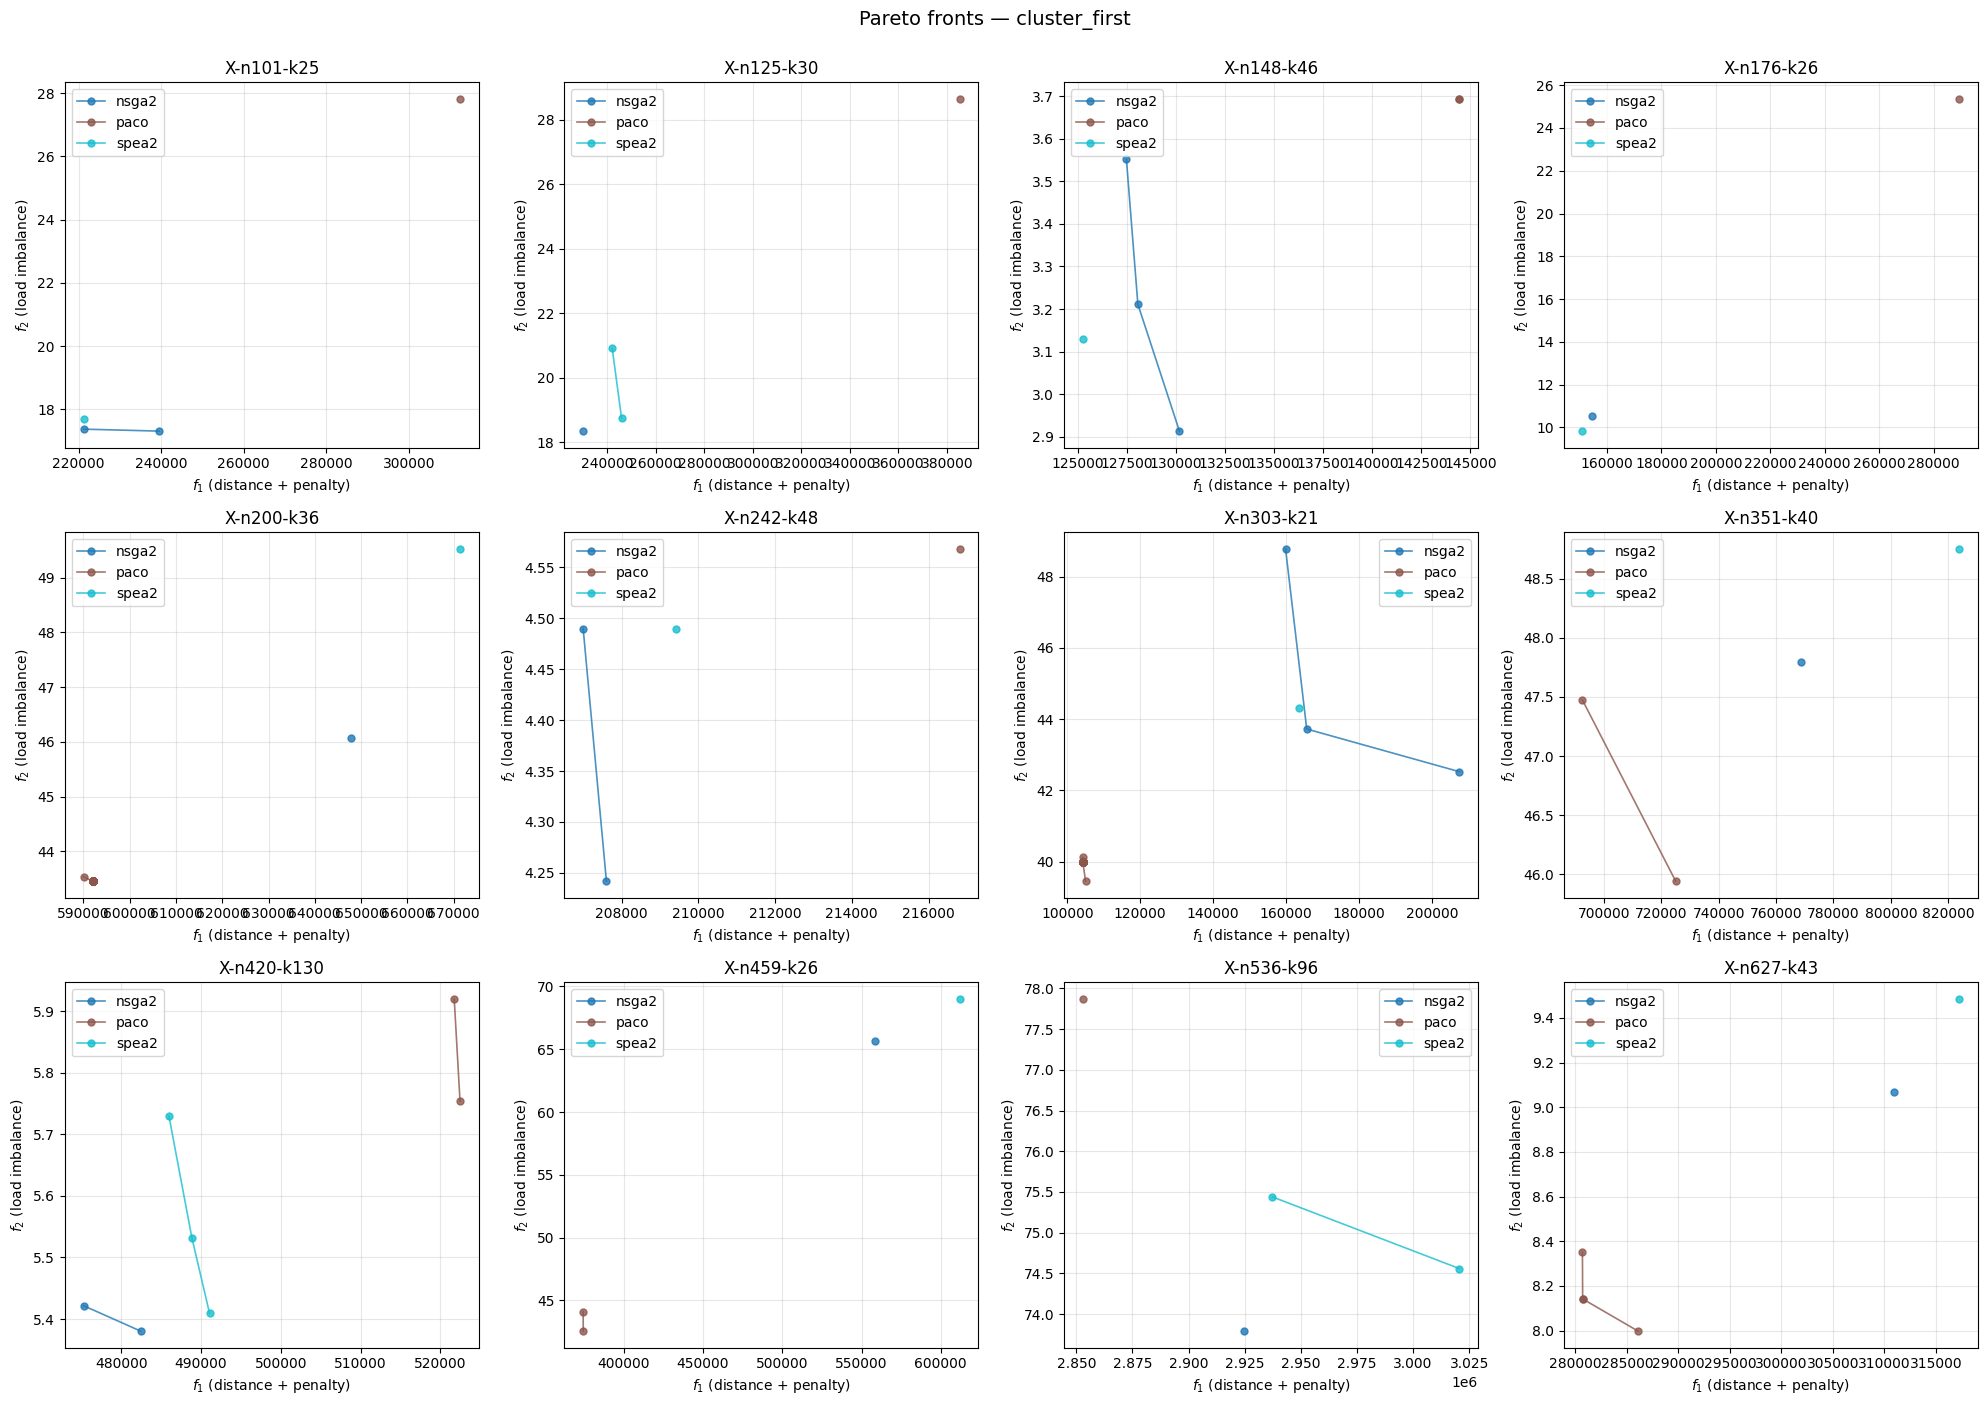

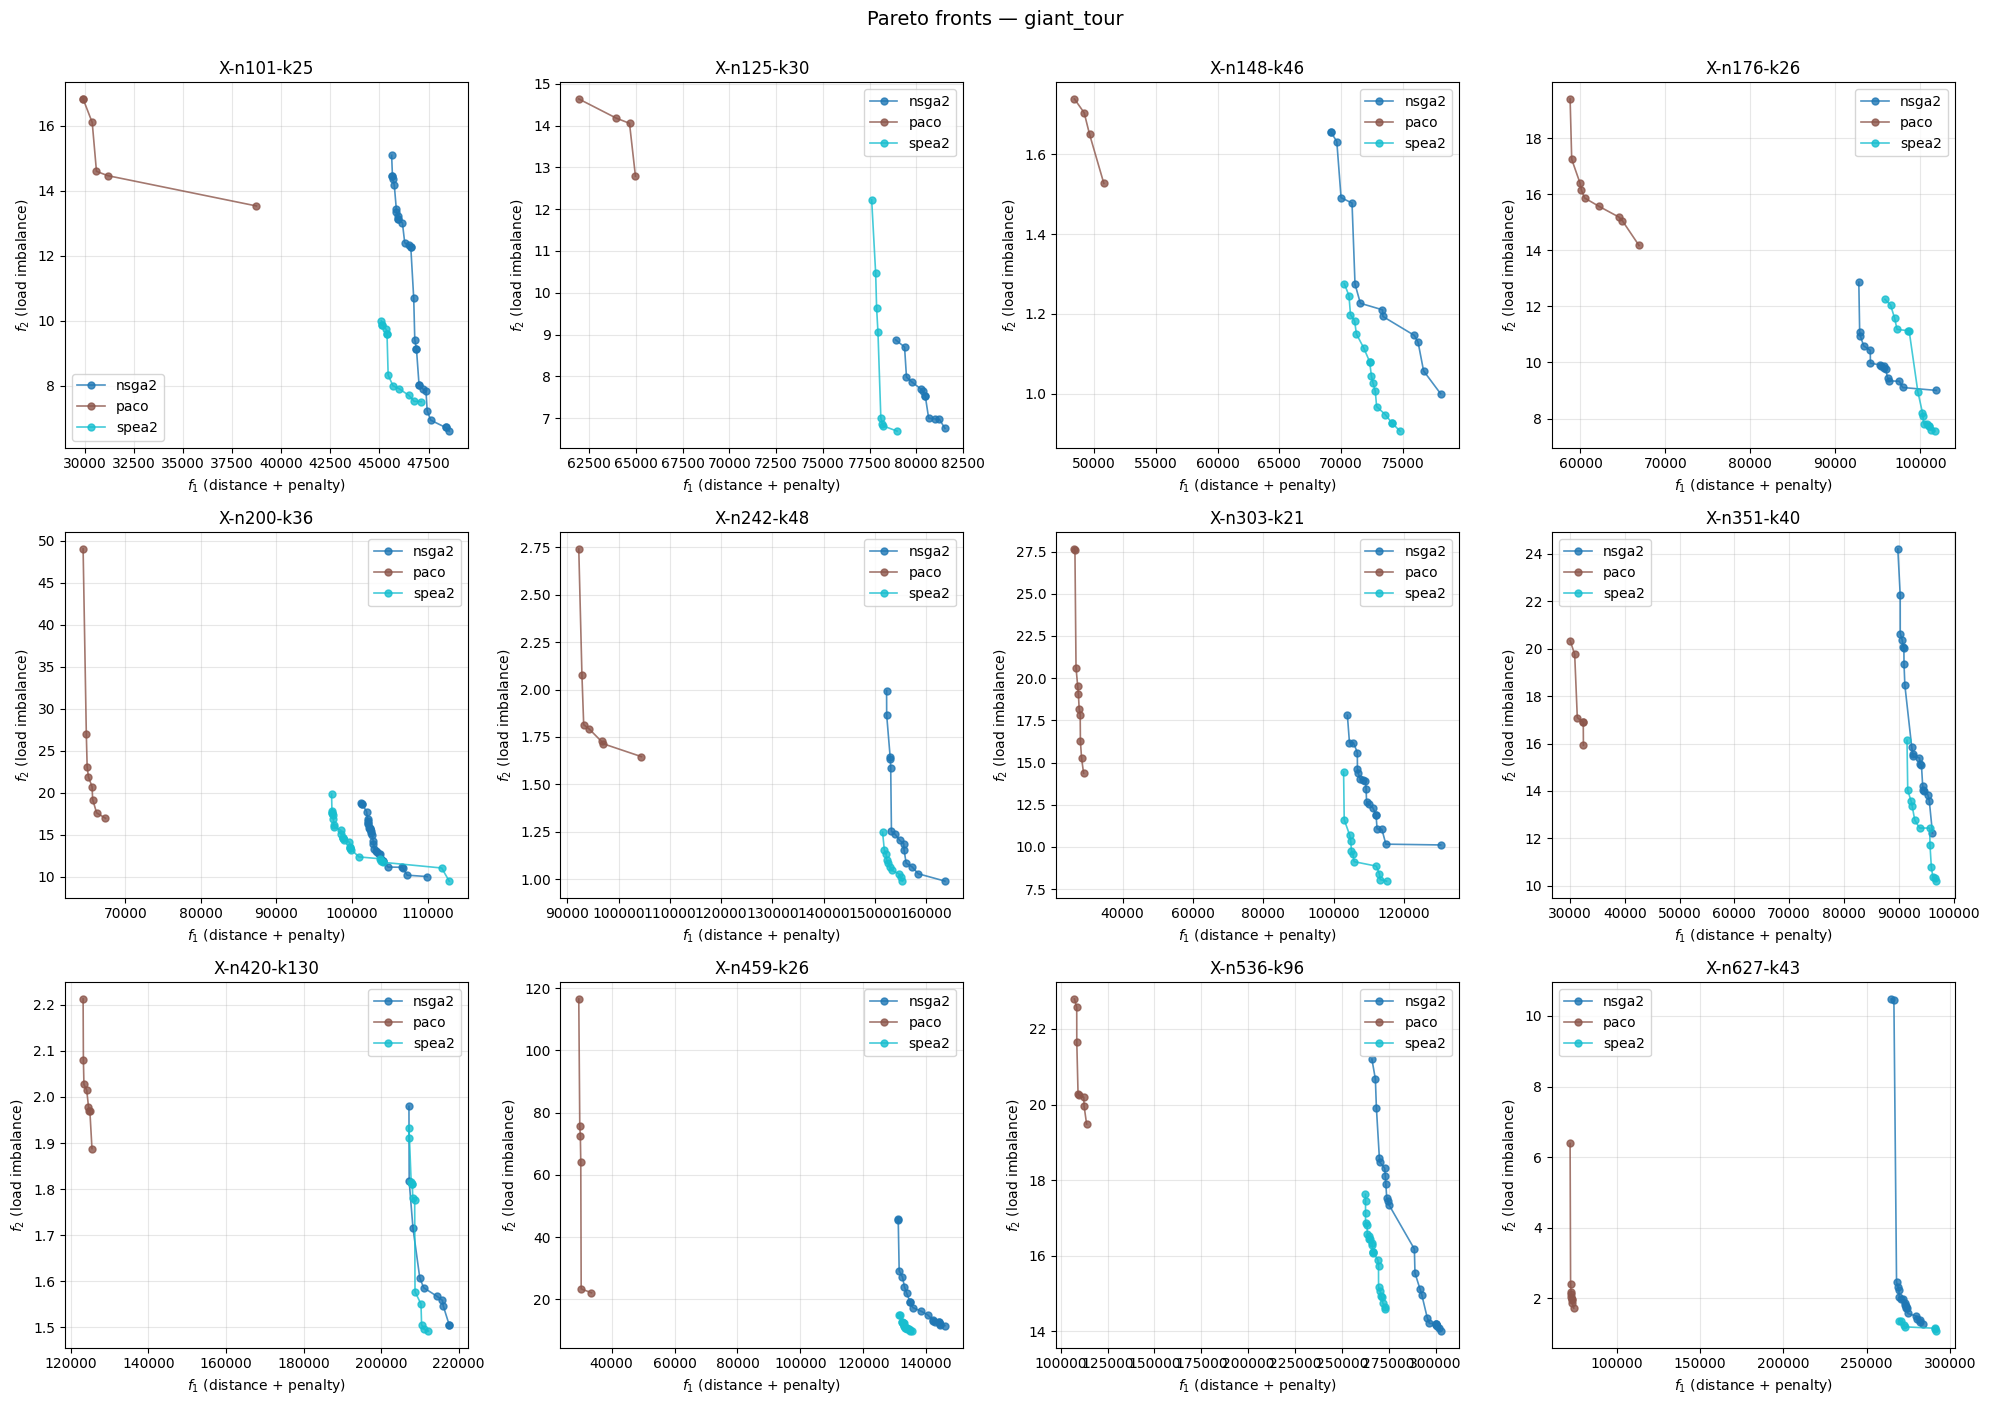

In [3]:
def median_hv_run_index(algo: str, rep: str, inst: str) -> int:
    """Return the run index whose HV is closest to the median across runs."""
    hvs = loader.compute_metric_series(algo, rep, inst, "hv")
    median = float(np.median(hvs))
    return int(np.argmin([abs(h - median) for h in hvs]))

for rep in representations:
    fig, axes = plt.subplots(3, 4, figsize=(20, 14))
    for ax, inst in zip(axes.flat, instances):
        fronts = {}
        for algo in algorithms:
            run_idx = median_hv_run_index(algo, rep, inst)
            fronts[algo] = loader.get_runs(algo, rep, inst)[run_idx]
        plot_pareto_fronts_overlay(fronts, ax=ax, title=inst)
    fig.suptitle(f"Pareto fronts — {rep}", y=1.00, fontsize=14)
    fig.tight_layout()
    plt.show()

## 4. Aggregate metric boxplots

For each (metric, representation), one boxplot summarizes performance across all instances. Each box contains 12 points — one median per instance computed from its 31 runs. This aggregates per-instance variability into a single comparable distribution per algorithm.

For HV and PF higher is better; for SP and GD lower is better.

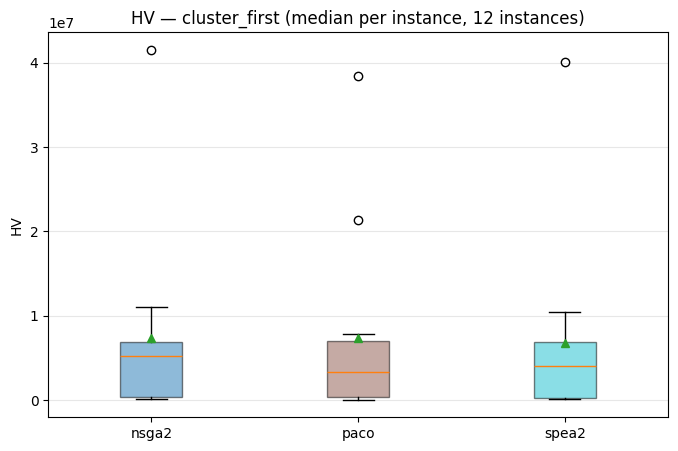

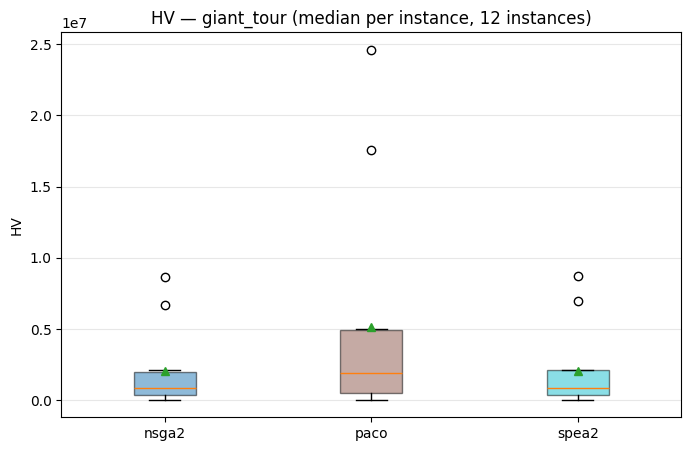

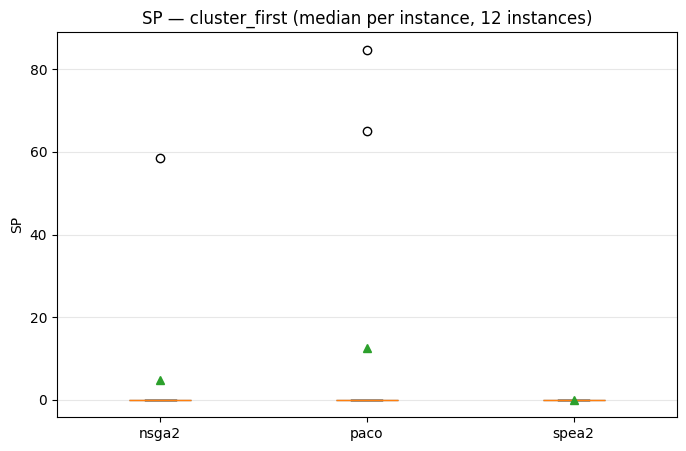

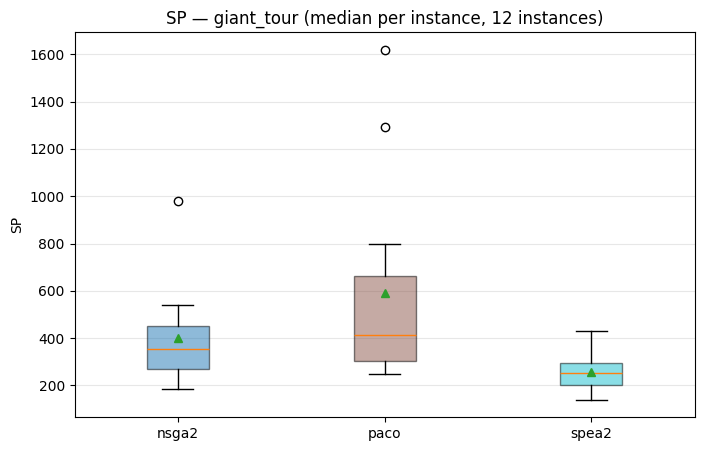

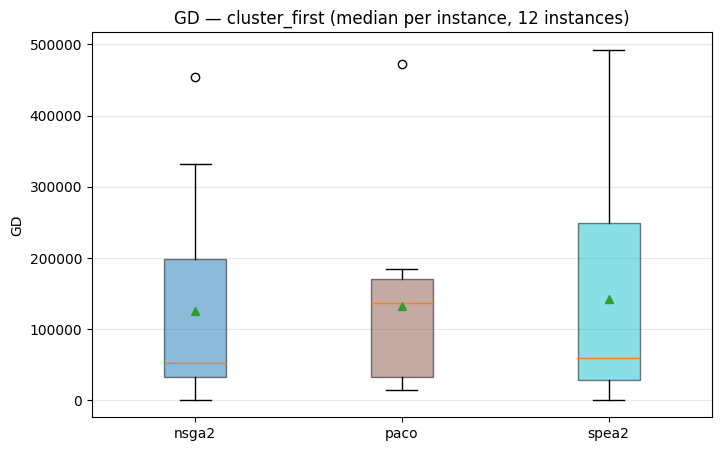

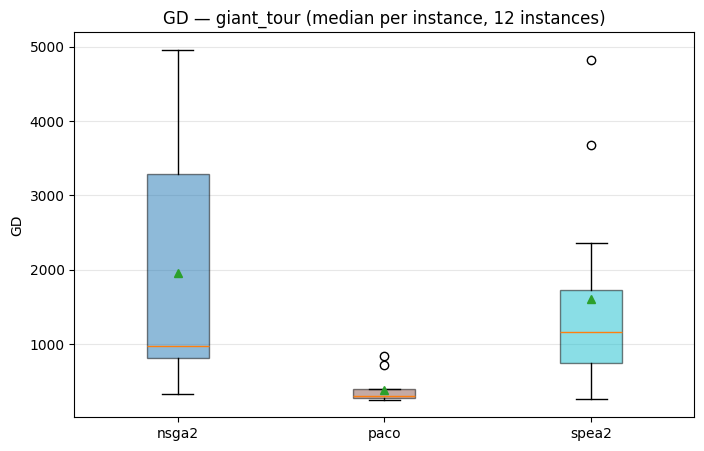

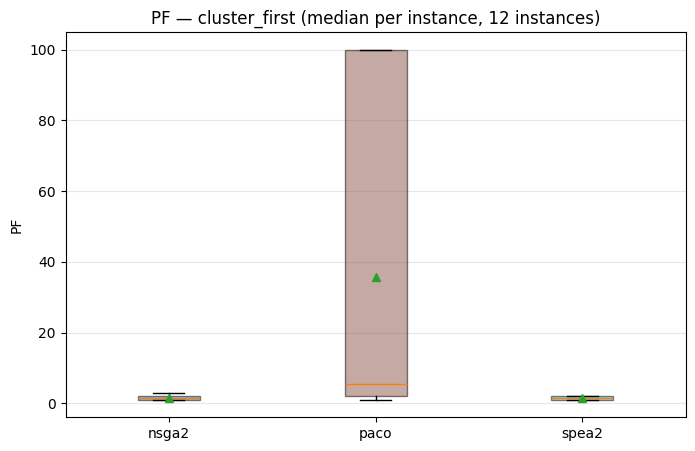

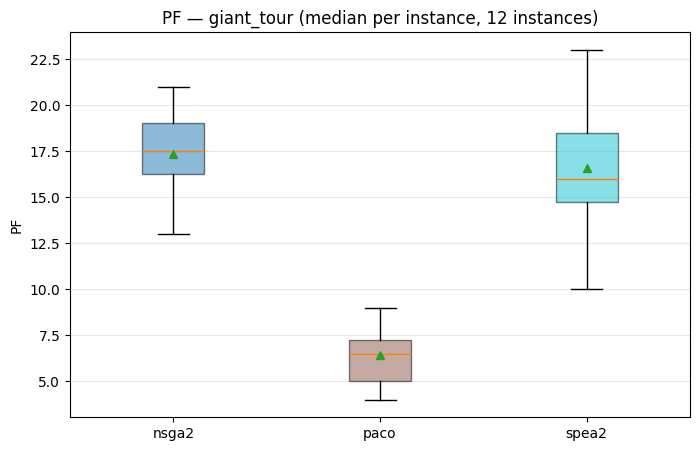

In [4]:
for metric in ["hv", "sp", "gd", "pf"]:
    for rep in representations:
        series = {}
        for algo in algorithms:
            medians = [
                float(np.median(loader.compute_metric_series(algo, rep, inst, metric)))
                for inst in instances
            ]
            series[algo] = medians

        fig, ax = plt.subplots(figsize=(8, 5))
        plot_metric_boxplots(
            series,
            metric_name=metric.upper(),
            ax=ax,
            title=f"{metric.upper()} — {rep} (median per instance, {len(instances)} instances)",
        )
        plt.show()

## 5. Best routes

For the representative instance, decode the knee-point solution from each algorithm's final archive and plot the resulting routes on the map. The knee point is the solution with the smallest normalized distance to the ideal point — a balanced trade-off between f1 and f2.

Chromosomes are read directly from the CSV files (one row per Pareto solution, with the chromosome stored as a comma-separated string), so the routes shown correspond to the actual experiment results, not to ad-hoc demo runs.

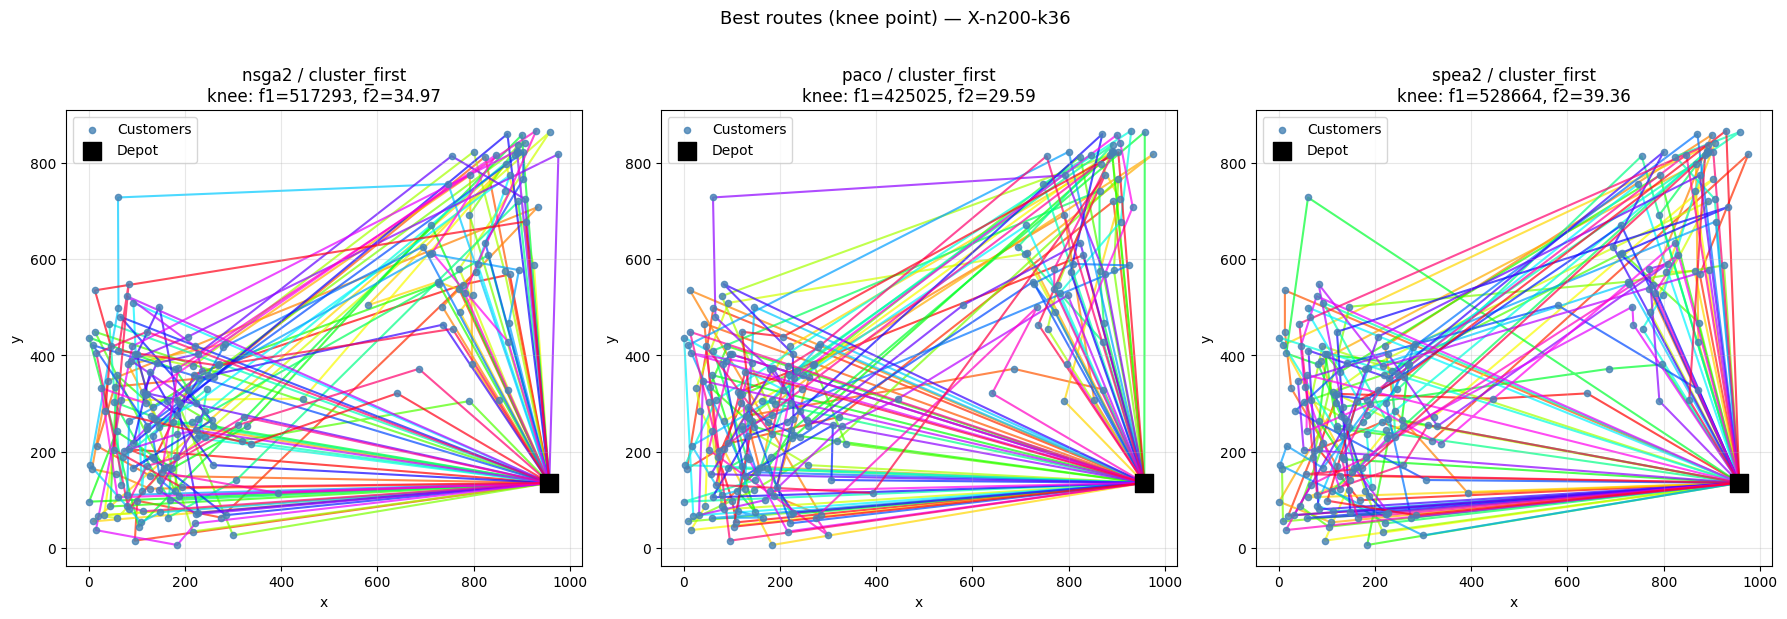

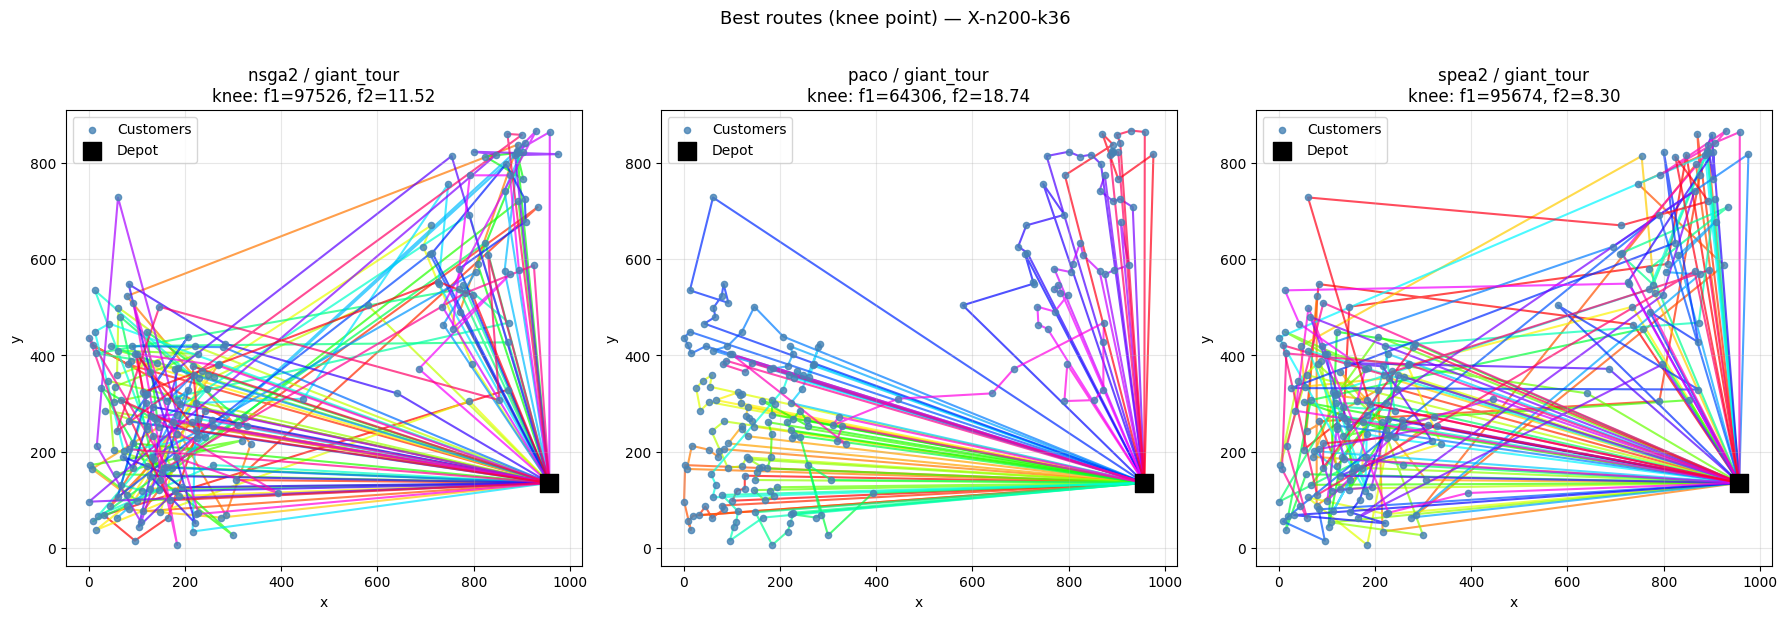

In [5]:
def parse_chromosome(s: str) -> list[int]:
    """Parse a comma-separated chromosome string from the CSV."""
    return [int(g) for g in s.split(",")]


def knee_point_from_csv(algo: str, rep: str, inst: str) -> tuple[list[int], float, float]:
    """Pick the knee-point solution from all solutions across all runs.

    Aggregates final-archive solutions from every run, then picks the
    one with the smallest normalized Euclidean distance to the ideal
    point (min f1, min f2). Returns (chromosome, f1, f2).
    """
    subset = loader.data[
        (loader.data["algorithm"] == algo)
        & (loader.data["representation"] == rep)
        & (loader.data["instance"] == inst)
    ]
    if subset.empty:
        raise ValueError(f"No data for {algo}/{rep}/{inst}")

    f1s = subset["f1"].values
    f2s = subset["f2"].values
    f1_min, f1_max = f1s.min(), f1s.max()
    f2_min, f2_max = f2s.min(), f2s.max()
    f1_range = (f1_max - f1_min) if f1_max > f1_min else 1.0
    f2_range = (f2_max - f2_min) if f2_max > f2_min else 1.0

    norm_dist = ((f1s - f1_min) / f1_range) ** 2 + ((f2s - f2_min) / f2_range) ** 2
    best_idx = int(np.argmin(norm_dist))
    row = subset.iloc[best_idx]
    return parse_chromosome(row["chromosome"]), float(row["f1"]), float(row["f2"])


instance_obj = parse_vrp_file(f"../data/{REPRESENTATIVE_INSTANCE}.vrp")

for rep in representations:
    decoder = (
        GiantTourDecoder(instance_obj)
        if rep == "giant_tour"
        else ClusterFirstDecoder(instance_obj)
    )
    fig, axes = plt.subplots(1, len(algorithms), figsize=(18, 6))
    for ax, algo in zip(axes, algorithms):
        chromosome, f1, f2 = knee_point_from_csv(algo, rep, REPRESENTATIVE_INSTANCE)
        routes = decoder.decode(chromosome)
        plot_instance(instance_obj, ax=ax)
        plot_routes(routes, instance_obj, ax=ax)
        ax.set_title(f"{algo} / {rep}\nknee: f1={f1:.0f}, f2={f2:.2f}")
    fig.suptitle(
        f"Best routes (knee point) — {REPRESENTATIVE_INSTANCE}",
        y=1.02, fontsize=13,
    )
    fig.tight_layout()
    plt.show()

## 6. Success Rate

Per the BAO course's Quality slide, success rate measures the fraction of final solutions that satisfy the problem constraints — here, that no route exceeds the vehicle capacity Q.

The giant_tour decoder is feasible by construction (it splits the giant tour at capacity), so success rate is always 100%. The cluster_first decoder assigns customers to vehicles without enforcing capacity, so infeasible solutions are penalized in f1 but still returned. Verifying success rate on the final archives quantifies how often each algorithm produces feasible solutions on cluster_first.

For each (algorithm, representation, instance), we decode every solution in every run's final archive and check capacity. The reported success rate is the fraction of feasible solutions across all 31 runs.


Success Rate (fraction of feasible solutions across 31 runs):


,cluster_first/X-n101-k25,cluster_first/X-n125-k30,cluster_first/X-n148-k46,cluster_first/X-n176-k26,cluster_first/X-n200-k36,cluster_first/X-n242-k48,cluster_first/X-n303-k21,cluster_first/X-n351-k40,cluster_first/X-n420-k130,cluster_first/X-n459-k26,...,giant_tour/X-n148-k46,giant_tour/X-n176-k26,giant_tour/X-n200-k36,giant_tour/X-n242-k48,giant_tour/X-n303-k21,giant_tour/X-n351-k40,giant_tour/X-n420-k130,giant_tour/X-n459-k26,giant_tour/X-n536-k96,giant_tour/X-n627-k43
nsga2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
paco,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
spea2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


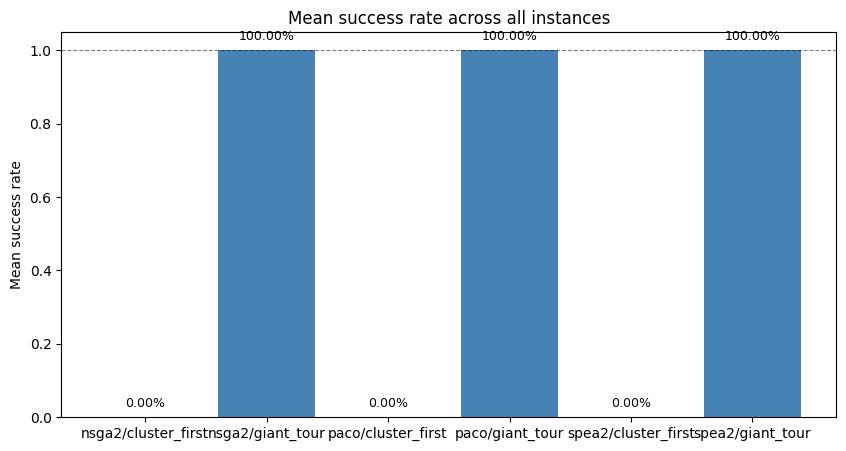

In [8]:
def is_feasible(routes, instance) -> bool:
    """Check that no route exceeds the vehicle capacity Q."""
    for route in routes:
        load = sum(instance.demands[c] for c in route)
        if load > instance.capacity:
            return False
    return True


# Cache decoded instances to avoid re-parsing
_instance_cache: dict[str, object] = {}

def get_instance(inst_name: str):
    if inst_name not in _instance_cache:
        _instance_cache[inst_name] = parse_vrp_file(f"../data/{inst_name}.vrp")
    return _instance_cache[inst_name]


def success_rate(algo: str, rep: str, inst: str) -> float:
    """Fraction of feasible solutions across all runs for this combo."""
    instance_obj = get_instance(inst)
    decoder = (
        GiantTourDecoder(instance_obj)
        if rep == "giant_tour"
        else ClusterFirstDecoder(instance_obj)
    )
    subset = loader.data[
        (loader.data["algorithm"] == algo)
        & (loader.data["representation"] == rep)
        & (loader.data["instance"] == inst)
    ]
    if subset.empty:
        return float("nan")

    feasible = 0
    total = 0
    for chromosome_str in subset["chromosome"]:
        chromosome = [int(g) for g in chromosome_str.split(",")]
        routes = decoder.decode(chromosome)
        total += 1
        if is_feasible(routes, instance_obj):
            feasible += 1
    return feasible / total if total > 0 else float("nan")


# Build the table
rows = {}
for algo in algorithms:
    row = {}
    for rep in representations:
        for inst in instances:
            row[f"{rep}/{inst}"] = success_rate(algo, rep, inst)
    rows[algo] = row

success_df = pd.DataFrame(rows).T
print("\nSuccess Rate (fraction of feasible solutions across 31 runs):")
display(success_df)

# Aggregate bar chart
fig, ax = plt.subplots(figsize=(10, 5))
agg = {}
for algo in algorithms:
    for rep in representations:
        rates = [success_rate(algo, rep, inst) for inst in instances]
        agg[f"{algo}/{rep}"] = float(np.mean(rates))

bars = ax.bar(agg.keys(), agg.values(), color="steelblue")
ax.set_ylabel("Mean success rate")
ax.set_ylim(0, 1.05)
ax.set_title("Mean success rate across all instances")
ax.axhline(1.0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
for bar, val in zip(bars, agg.values()):
    ax.text(
        bar.get_x() + bar.get_width() / 2, val + 0.02,
        f"{val:.2%}", ha="center", va="bottom", fontsize=9
    )

**Discussion.** The 100% success rate on giant_tour reflects the decoder's built-in capacity-aware split: routes are constructed by accumulating customers until adding one more would exceed Q, then a new route starts. Feasibility is therefore structural and independent of the algorithm.

On cluster_first, capacity is not enforced by the decoder; the algorithm assigns customers to vehicles via the chromosome, and the resulting routes may exceed Q. We applied a penalty-based constraint handling approach (penalty_weight=1000 added to f1 per unit of overload), but the success rate of approximately 0% across all three algorithms shows that this penalty alone is insufficient to drive the population into the feasible region for the chosen problem sizes. A dedicated repair operator that redistributes overloaded customers would likely be required to obtain feasible solutions consistently with this representation.

## 7. Convergence analysis

For every instance and every representation, we extract the per-generation history saved during the experiments (chromosomes and fitness for the entire population at every generation, across all 31 runs).

Four convergence views are shown, each as a 3×4 grid covering all 12 instances per representation:

- **f1 convergence** — max, mean, and min of f1 within each generation, averaged across runs.
- **f2 convergence** — same for f2.
- **Chromosome convergence** — mean per-position homogeneity in the population (the fraction of the population that carries the most common gene at each position, averaged over positions). Rises towards 1 as the population collapses to similar chromosomes.
- **Diversity** — number of distinct chromosomes in the population per generation, averaged across runs. Falls as the population converges; stays high if exploration is sustained.

Curves are shown per algorithm. Histories for all 12 instances × 3 algorithms × 2 representations are loaded from the .npz files persisted by the experiment pipeline.

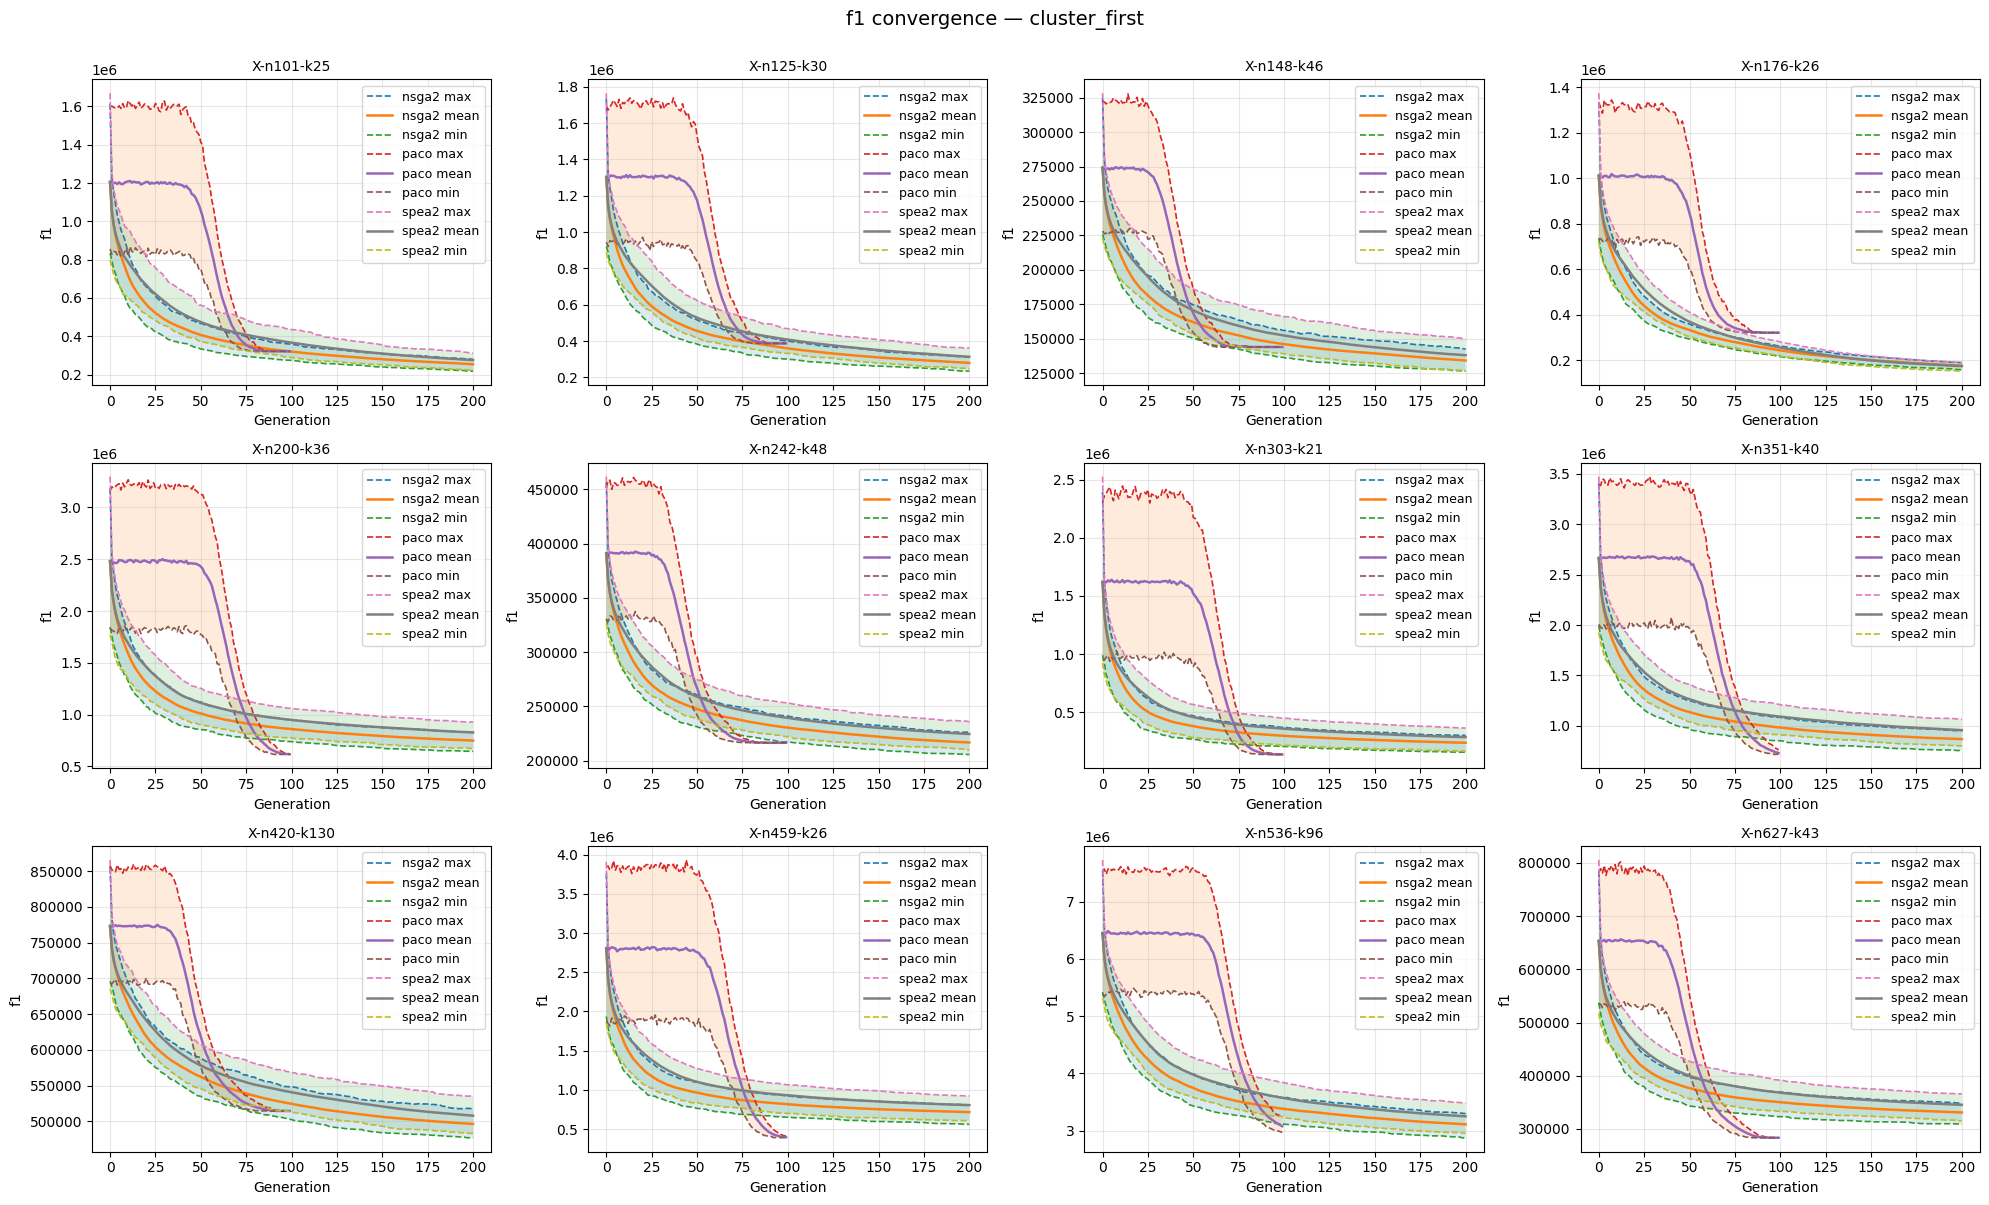

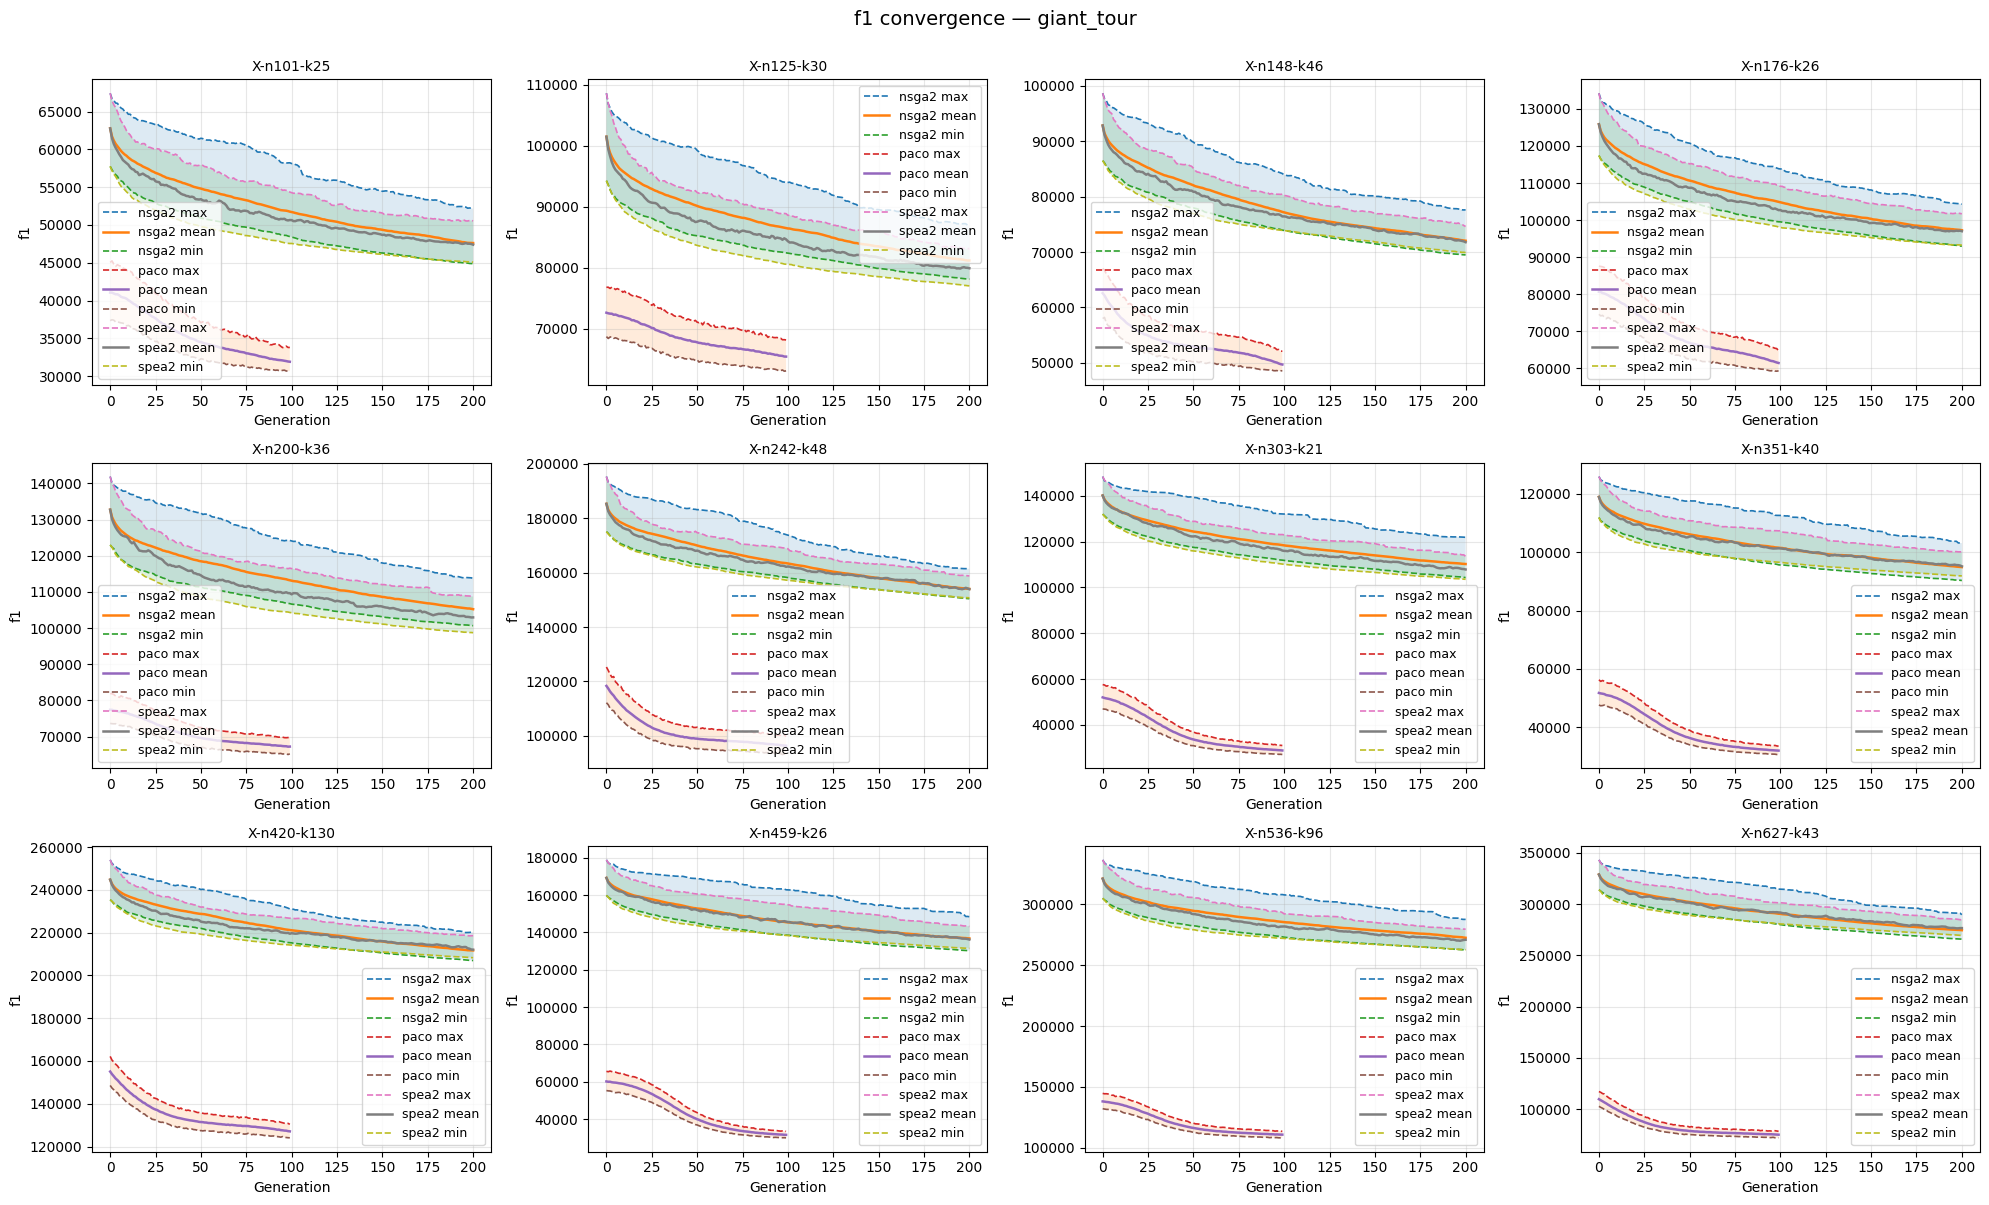

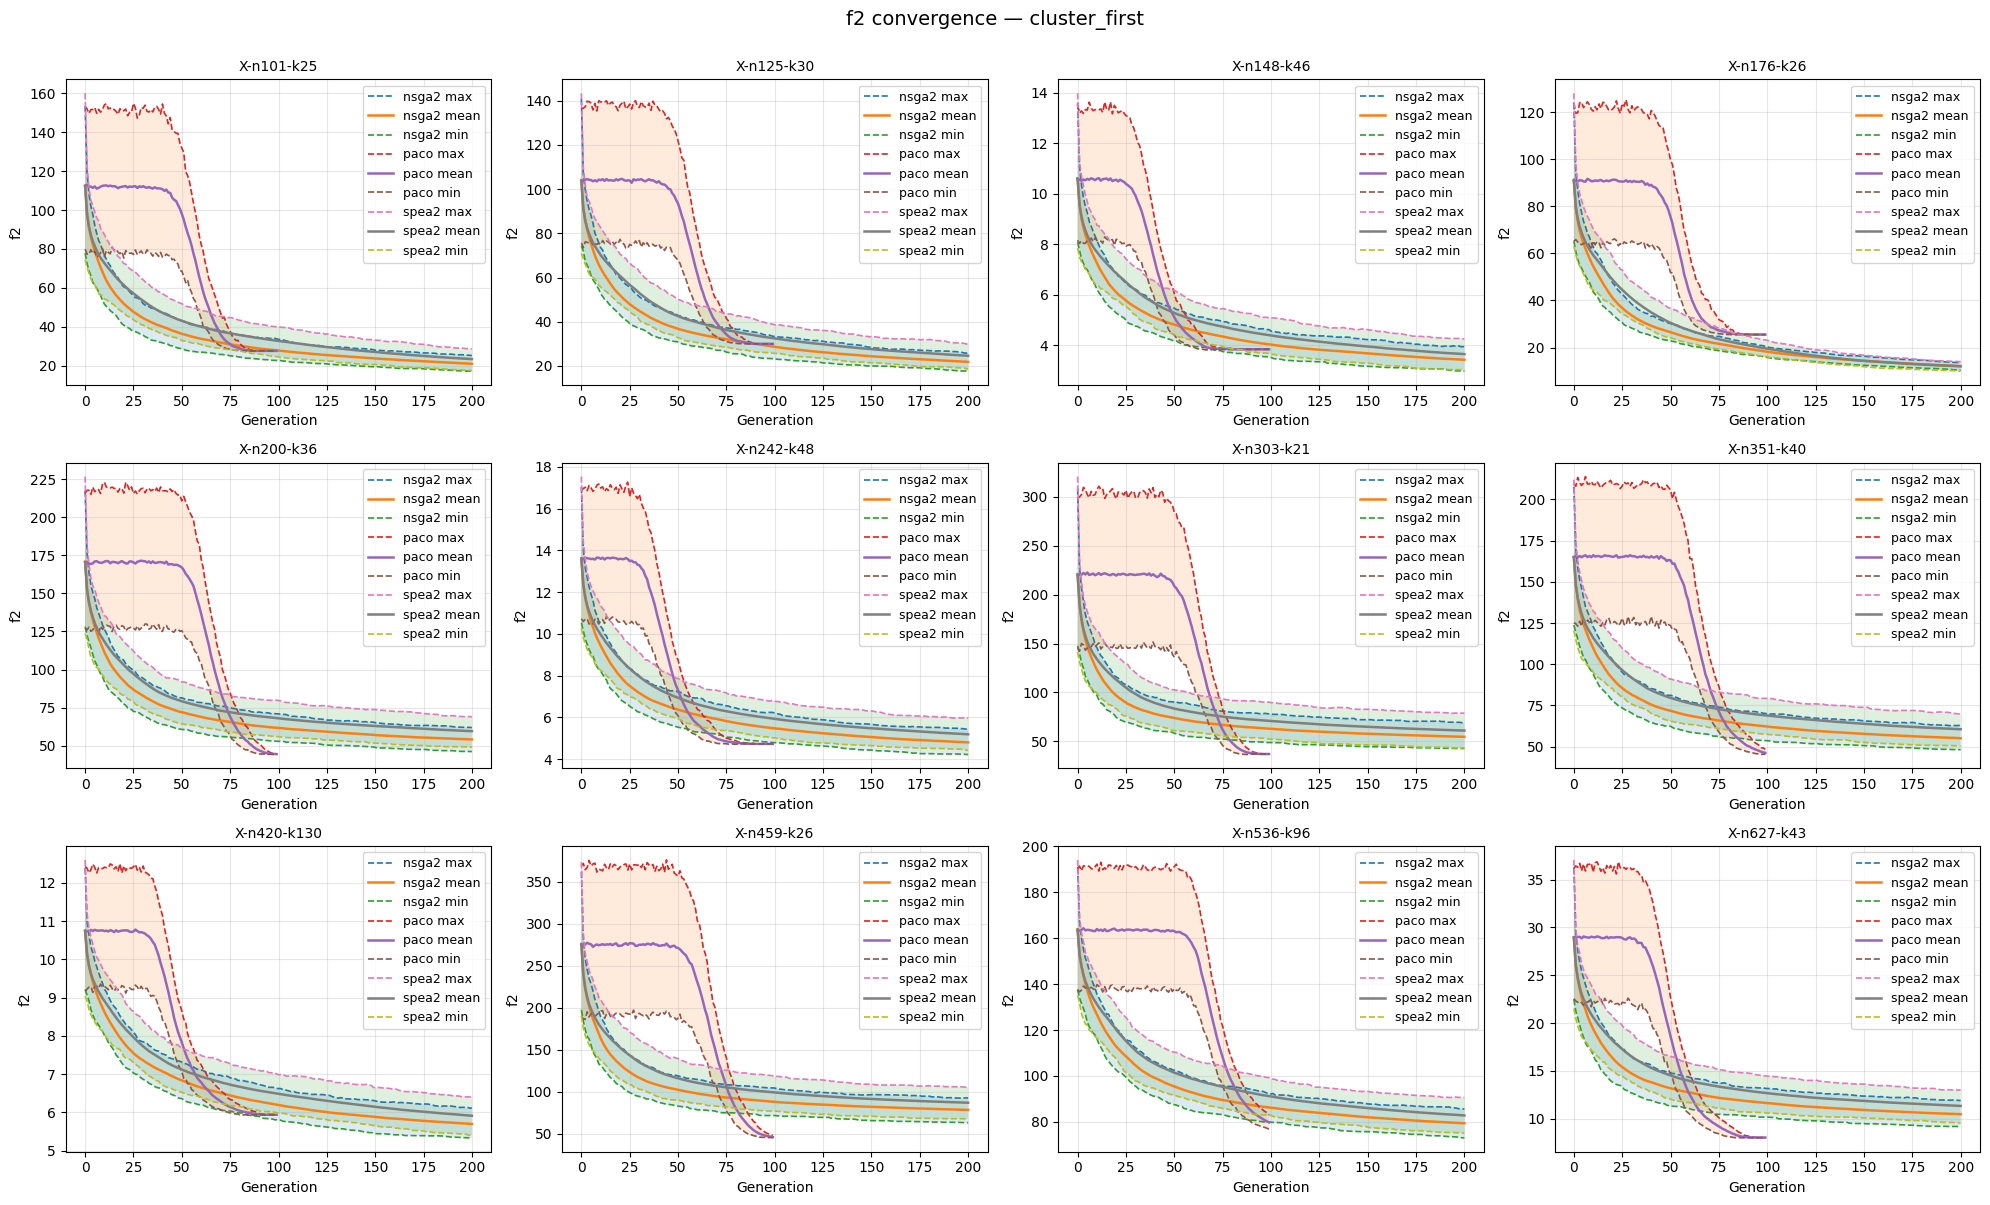

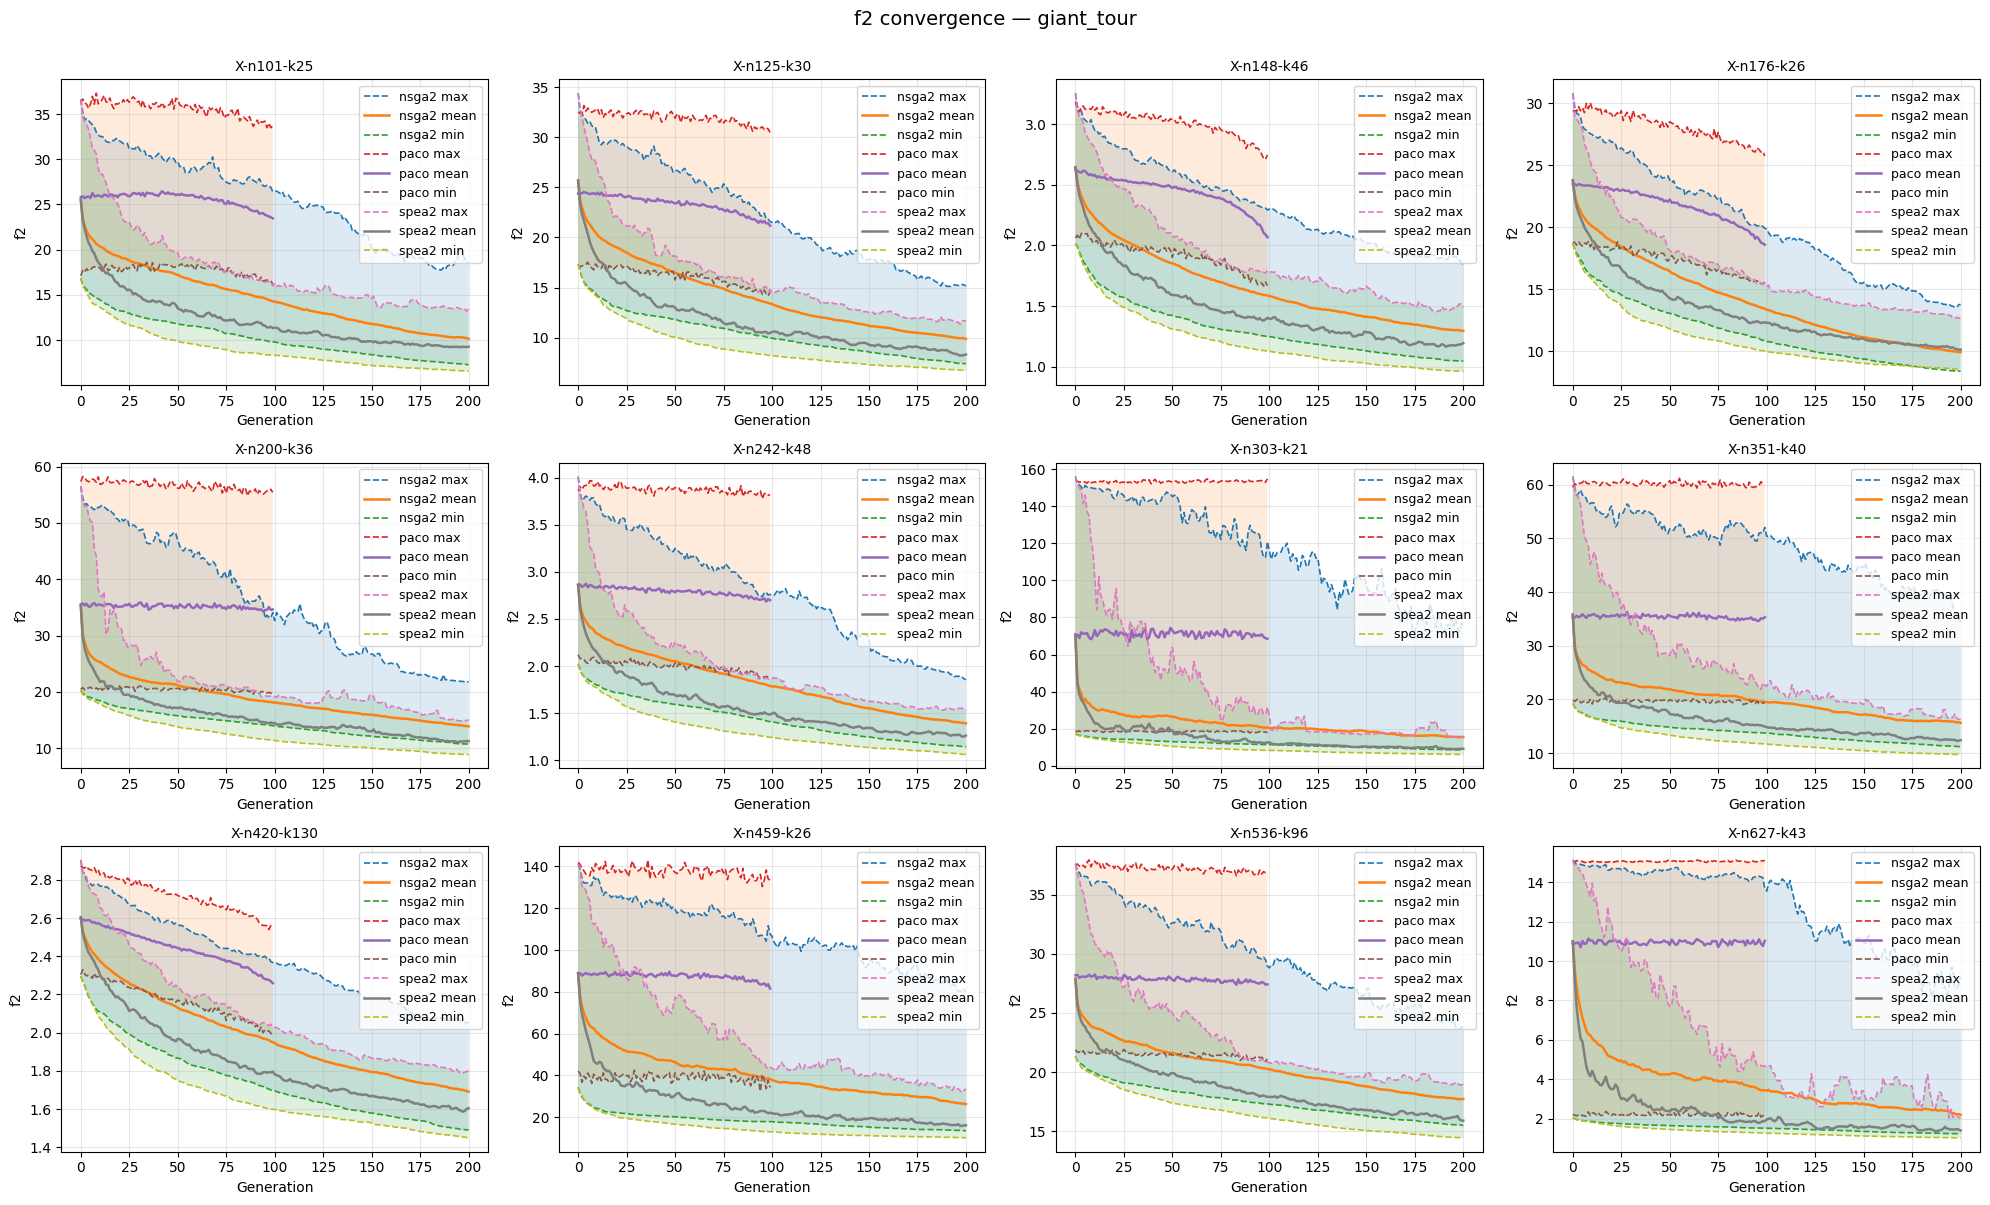

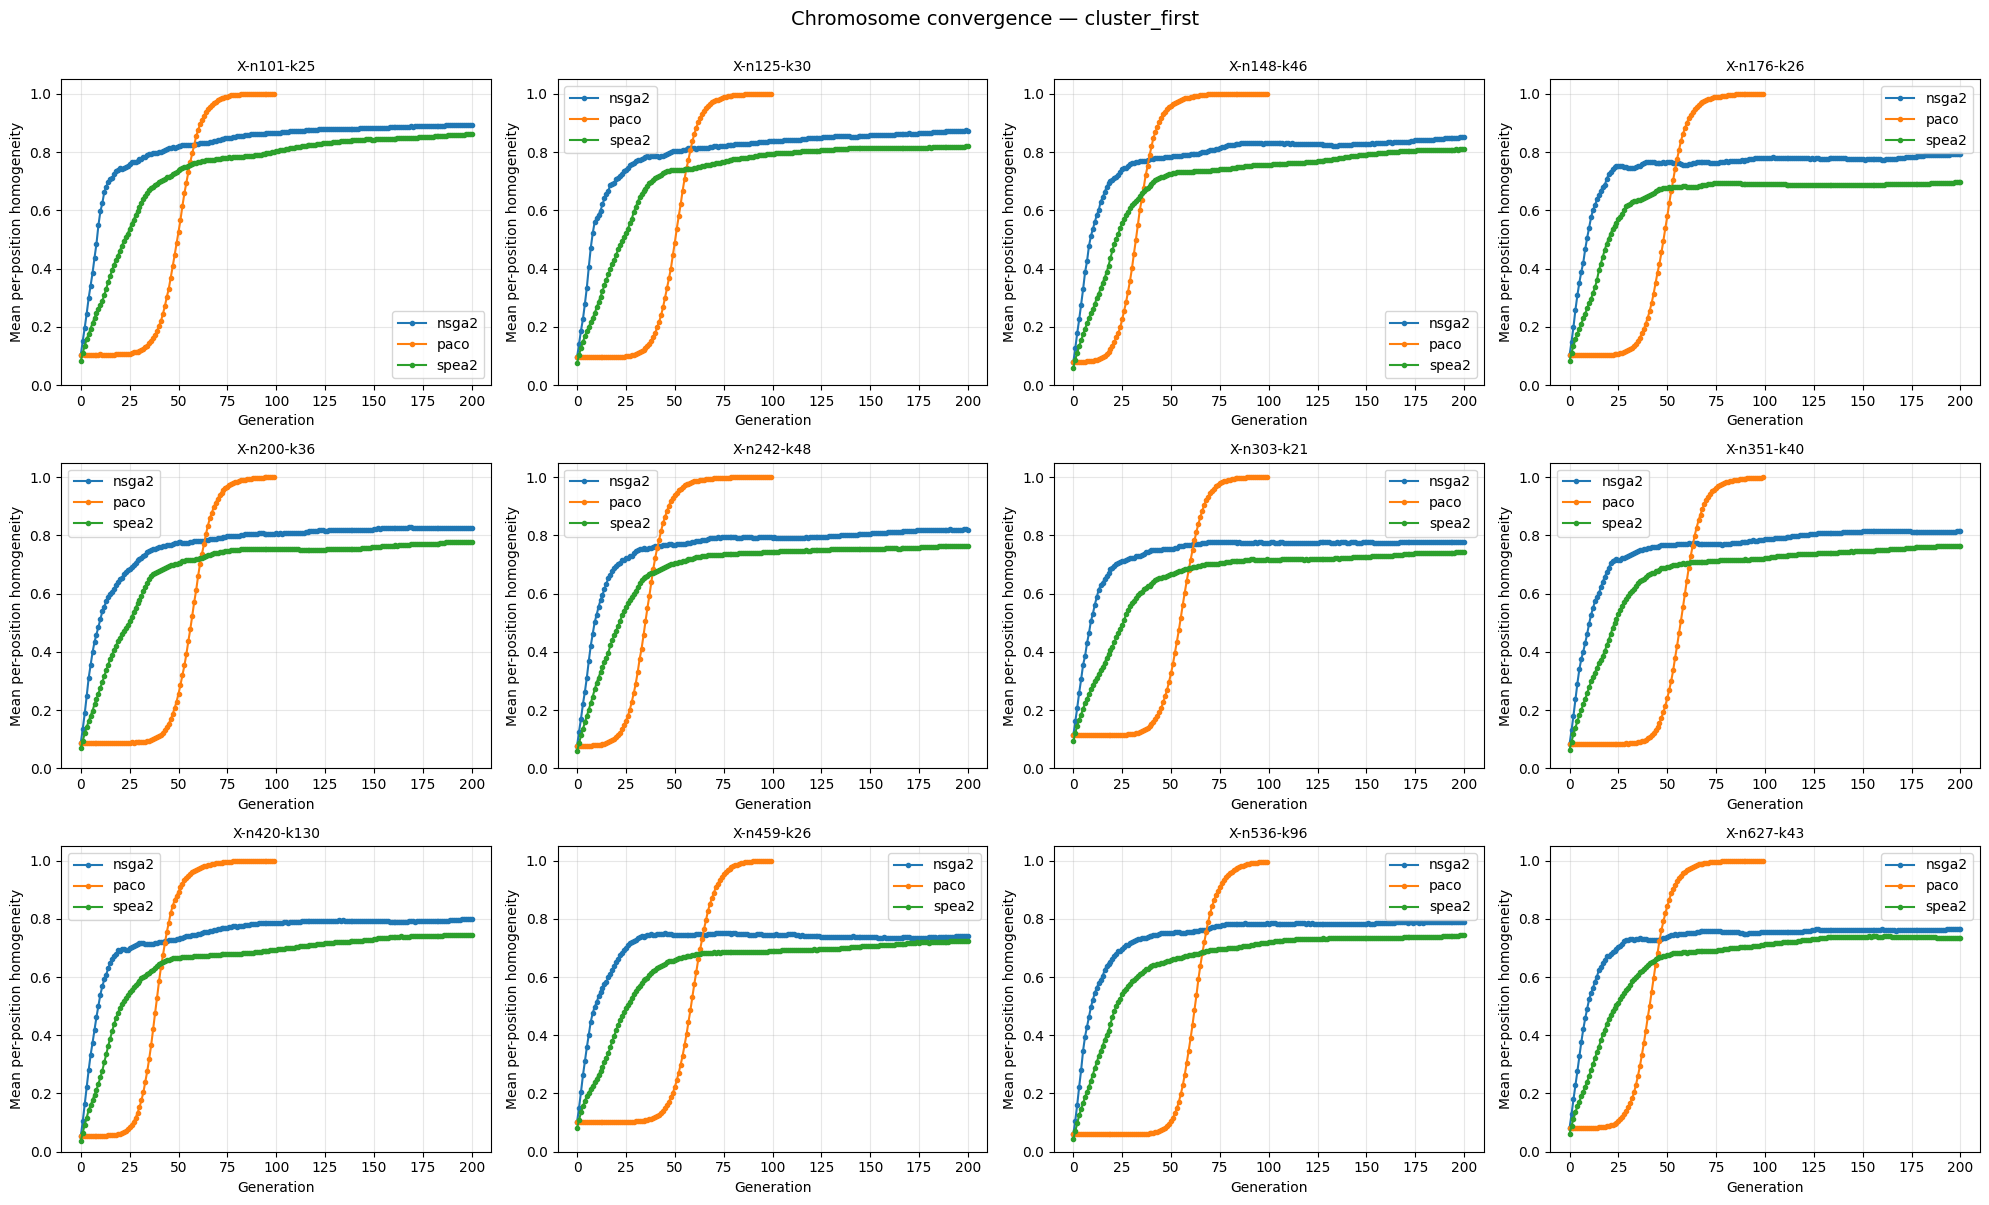

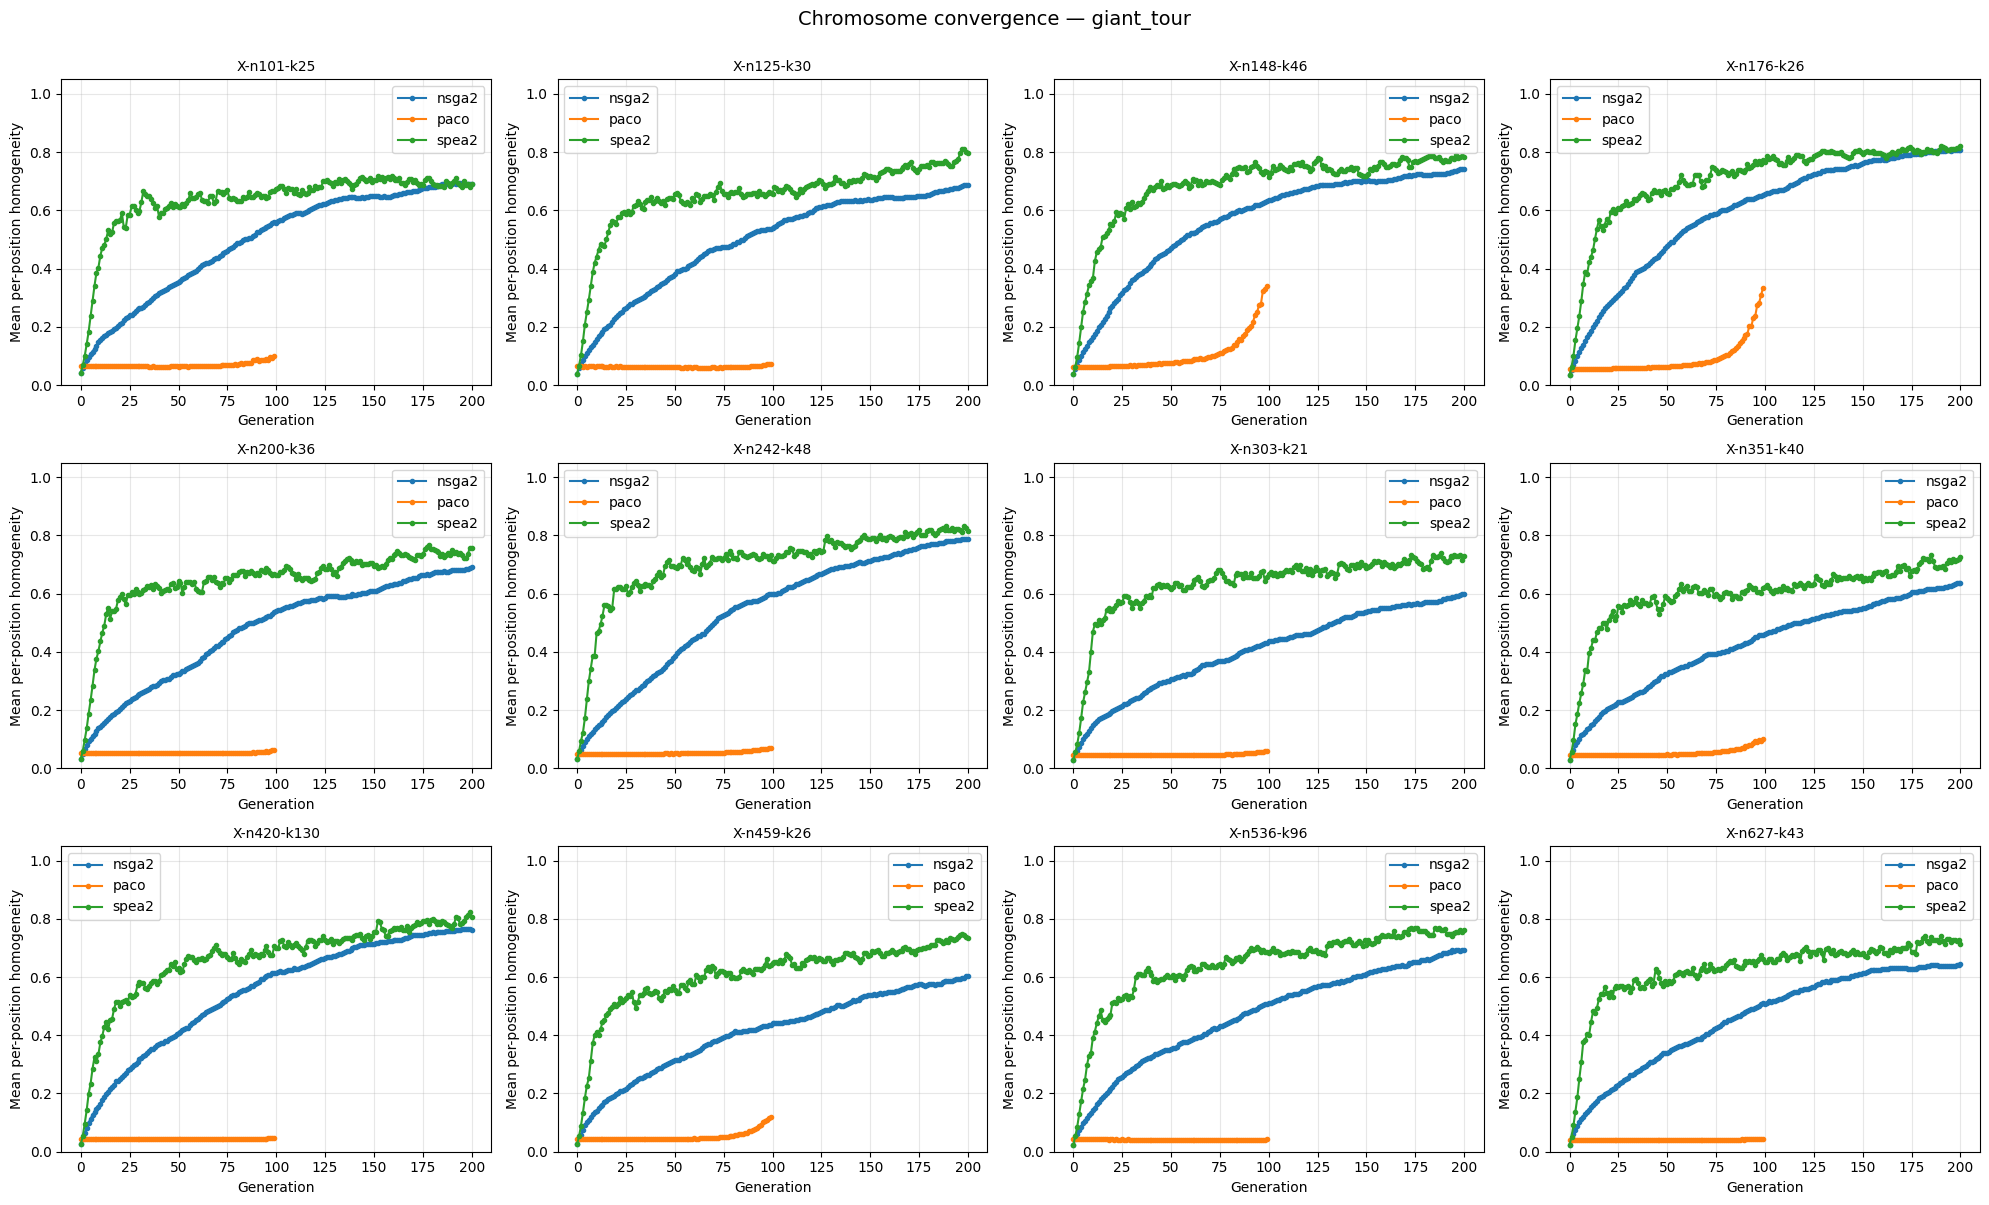

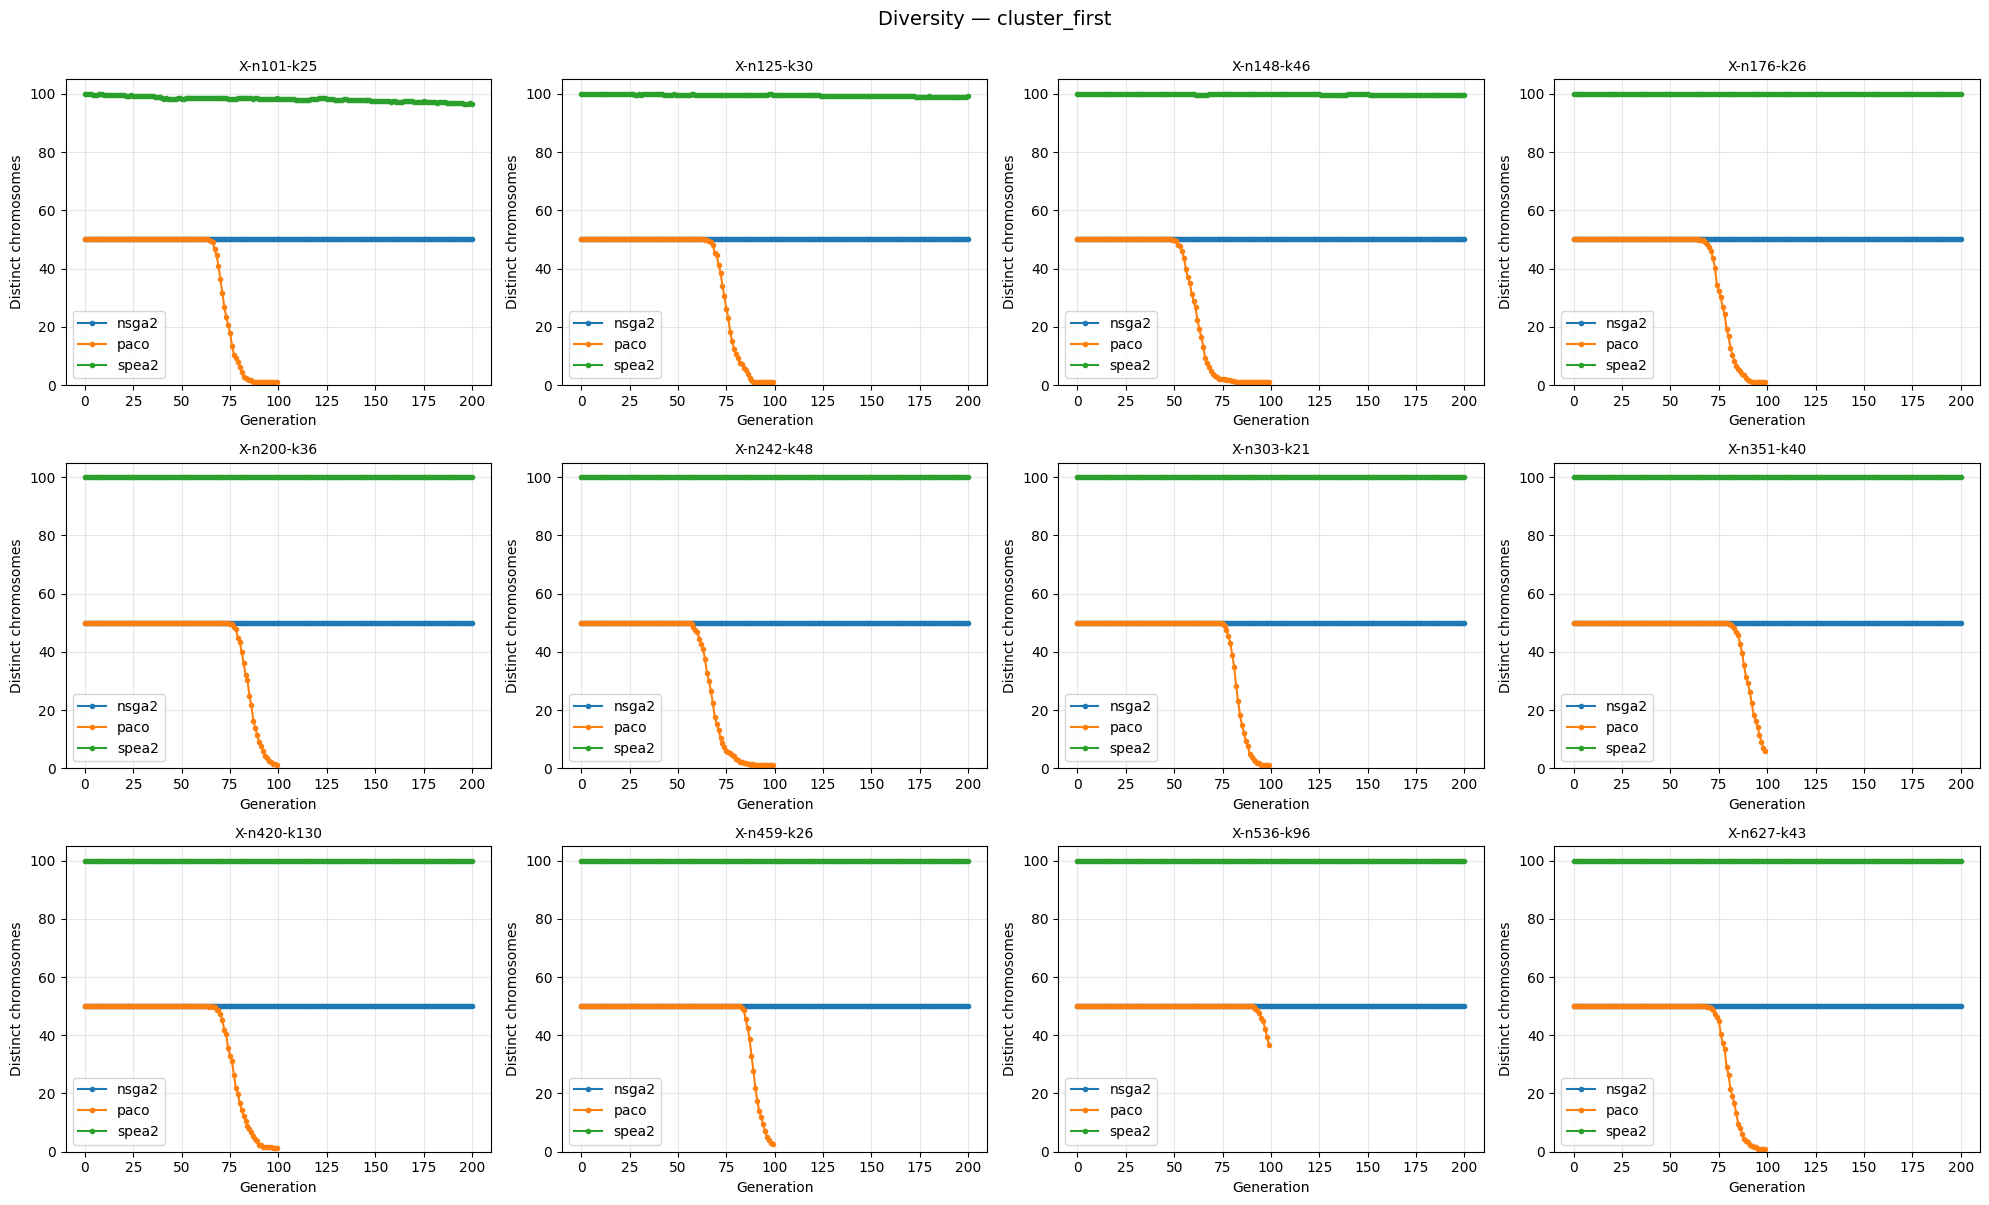

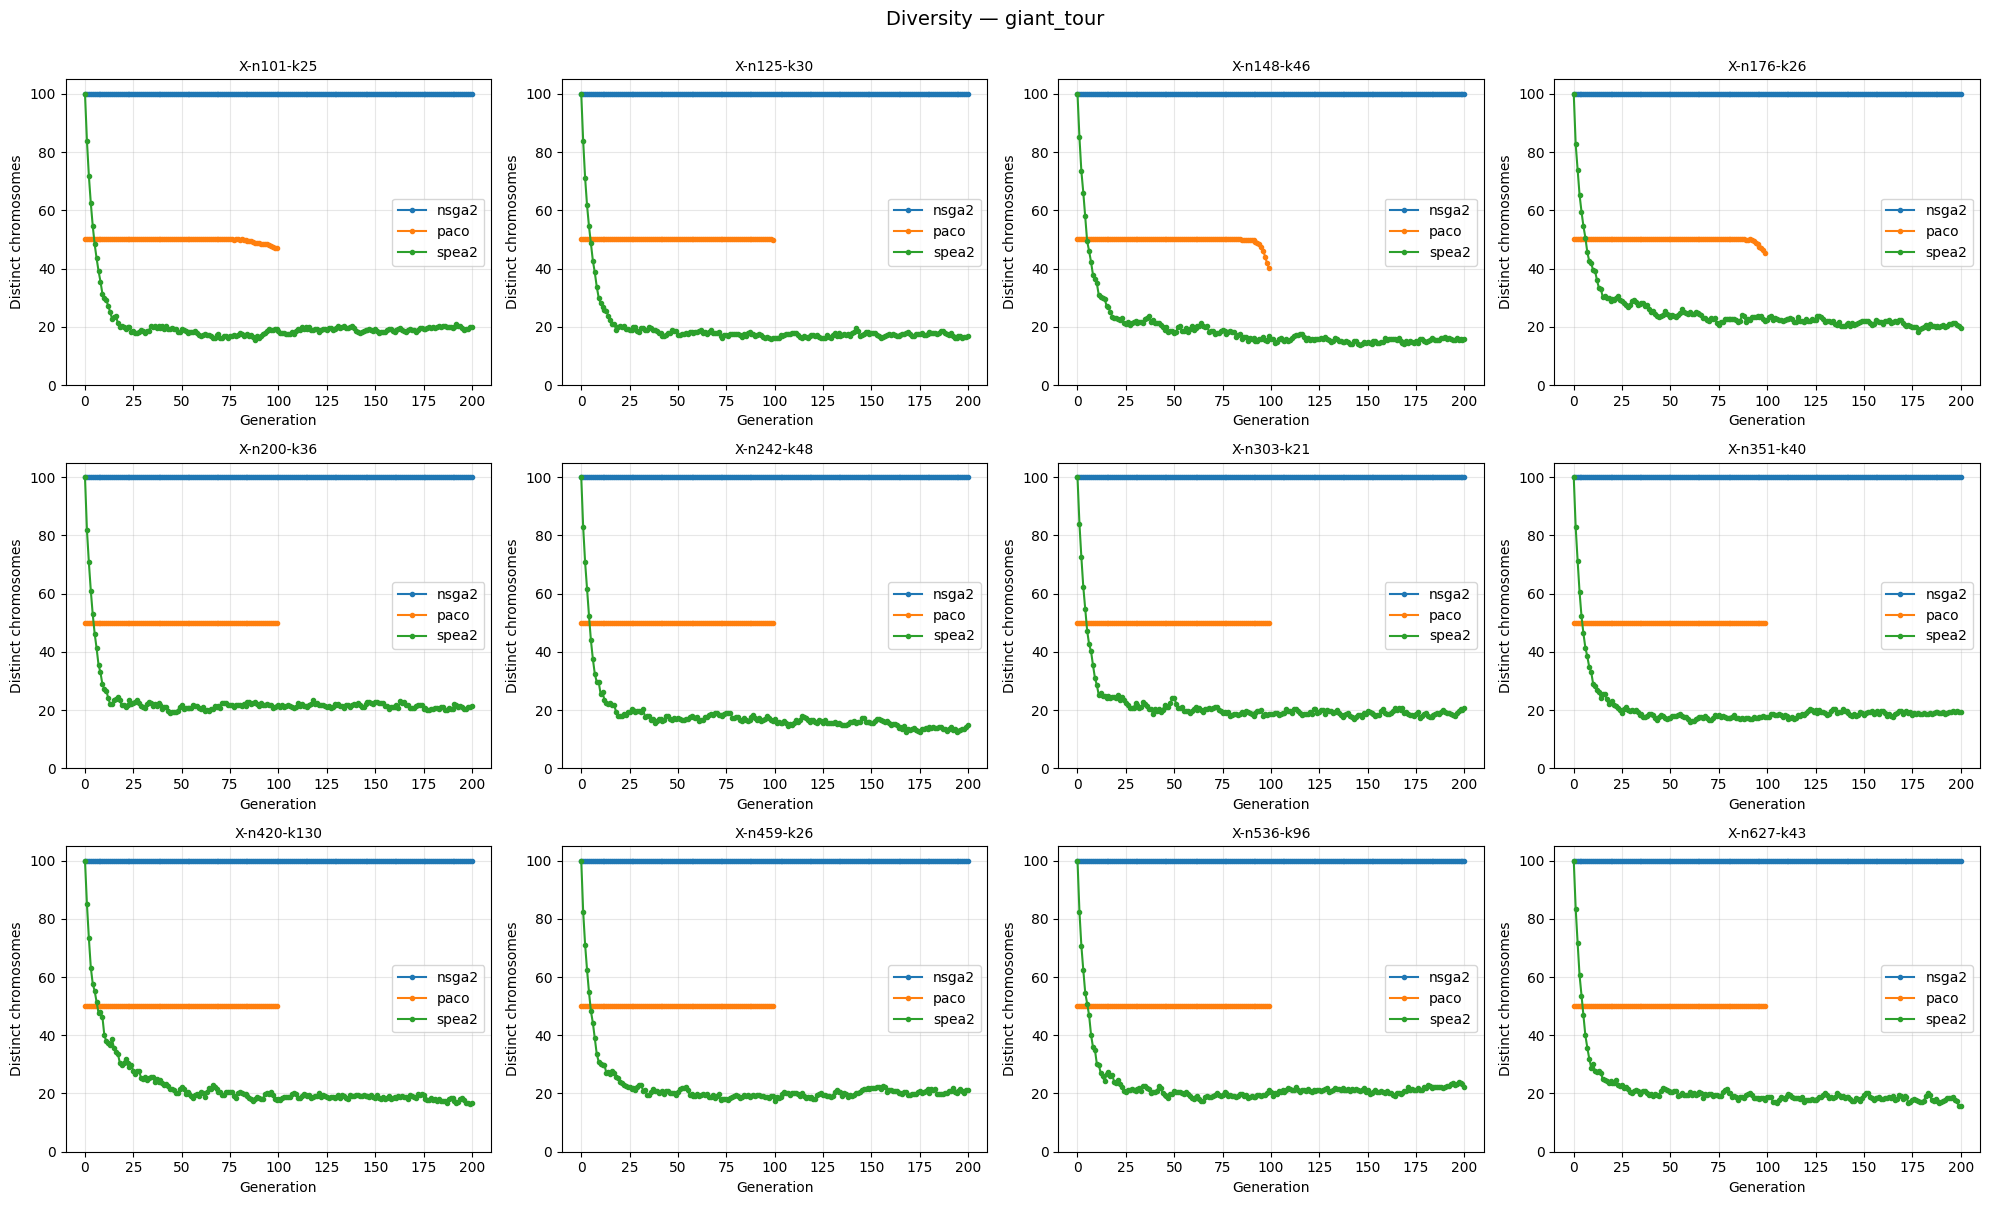

In [13]:
def history_for(algo: str, rep: str, inst: str) -> dict:
    """Wrapper around loader.load_history with error handling."""
    return loader.load_history(algo, rep, inst)


def plot_convergence_grid(plotter_fn, title_suffix: str, rep: str, **plot_kwargs):
    """Plot a 3x4 grid of one convergence kind across all instances.

    plotter_fn receives (data_array, ax, label) for each algorithm.
    """
    fig, axes = plt.subplots(3, 4, figsize=(20, 12))
    for ax, inst in zip(axes.flat, instances):
        for algo in algorithms:
            hist = history_for(algo, rep, inst)
            plotter_fn(hist, ax=ax, label=algo, **plot_kwargs)
        ax.set_title(inst, fontsize=10)
    fig.suptitle(f"{title_suffix} — {rep}", y=1.00, fontsize=14)
    fig.tight_layout()
    plt.show()


# 7a. f1 convergence
for rep in representations:
    plot_convergence_grid(
        lambda hist, ax, label: plot_fitness_convergence(
            hist["f1"], objective_name="f1", ax=ax, label_prefix=label
        ),
        "f1 convergence",
        rep,
    )

# 7b. f2 convergence
for rep in representations:
    plot_convergence_grid(
        lambda hist, ax, label: plot_fitness_convergence(
            hist["f2"], objective_name="f2", ax=ax, label_prefix=label
        ),
        "f2 convergence",
        rep,
    )

# 7c. Chromosome convergence
for rep in representations:
    plot_convergence_grid(
        lambda hist, ax, label: plot_chromosome_convergence(
            hist["chromosomes"], ax=ax, label=label
        ),
        "Chromosome convergence",
        rep,
    )

# 7d. Diversity
for rep in representations:
    plot_convergence_grid(
        lambda hist, ax, label: plot_diversity(
            hist["chromosomes"], ax=ax, label=label
        ),
        "Diversity",
        rep,
    )

## 8. Statistical tests

Two complementary tests assess whether the algorithms differ statistically:

- **Pairwise Wilcoxon signed-rank test (1 vs 1):** for each algorithm pair and each instance, compares the 31-run series on every metric. Reports two-sided p-values with significance marked at α = 0.05.

- **Friedman + Shaffer post-hoc (N vs N):** aggregates the 31 runs per (algorithm, instance) to a single median value, then tests whether the three algorithms differ jointly across the 12 instances. The Shaffer post-hoc corrects for multiple comparisons. Results are visualized as a graph where edges connect algorithms that are NOT significantly different — disconnected algorithms differ significantly.

For HV and PF higher is better; for SP and GD lower is better. The `maximize` flag inverts the ranking direction accordingly so that "lower rank = better" holds uniformly in the output.

In [14]:
pairs = [("nsga2", "spea2"), ("nsga2", "paco"), ("spea2", "paco")]


def format_p(p: float, significant: bool) -> str:
    marker = " *" if significant else ""
    return f"{p:.3g}{marker}"


for metric in ["hv", "sp", "gd", "pf"]:
    for rep in representations:
        rows = {}
        for inst in instances:
            row = {}
            for a, b in pairs:
                va = loader.compute_metric_series(a, rep, inst, metric)
                vb = loader.compute_metric_series(b, rep, inst, metric)
                res = wilcoxon_test(va, vb, alpha=ALPHA)
                row[f"{a} vs {b}"] = format_p(res["p_value"], res["significant"])
            rows[inst] = row
        print(f"\n=== Wilcoxon p-values — {metric.upper()} — {rep} (* = significant at α={ALPHA}) ===")
        display(pd.DataFrame(rows).T)


=== Wilcoxon p-values — HV — cluster_first (* = significant at α=0.05) ===


,nsga2 vs spea2,nsga2 vs paco,spea2 vs paco
X-n101-k25,0.581,9.31e-10 *,1.86e-09 *
X-n125-k30,0.0356 *,9.31e-10 *,9.31e-10 *
X-n148-k46,0.517,1.86e-09 *,1.3e-08 *
X-n176-k26,0.202,9.31e-10 *,9.31e-10 *
X-n200-k36,0.011 *,0.026 *,0.000237 *
X-n242-k48,0.0027 *,0.000541 *,0.0635
X-n303-k21,0.765,6.11e-06 *,6.11e-06 *
X-n351-k40,0.000644 *,0.00136 *,3.18e-05 *
X-n420-k130,0.00233 *,1.57e-07 *,1.05e-05 *
X-n459-k26,0.00414 *,2.33e-08 *,9.31e-10 *



=== Wilcoxon p-values — HV — giant_tour (* = significant at α=0.05) ===


,nsga2 vs spea2,nsga2 vs paco,spea2 vs paco
X-n101-k25,0.217,9.31e-10 *,2.79e-09 *
X-n125-k30,0.00136 *,1.35e-05 *,0.0456 *
X-n148-k46,0.146,9.31e-10 *,9.31e-10 *
X-n176-k26,0.468,9.31e-10 *,9.31e-10 *
X-n200-k36,0.00709 *,9.31e-10 *,9.31e-10 *
X-n242-k48,0.337,9.31e-10 *,9.31e-10 *
X-n303-k21,0.0246 *,9.31e-10 *,9.31e-10 *
X-n351-k40,0.555,9.31e-10 *,9.31e-10 *
X-n420-k130,0.399,9.31e-10 *,9.31e-10 *
X-n459-k26,0.765,9.31e-10 *,9.31e-10 *



=== Wilcoxon p-values — SP — cluster_first (* = significant at α=0.05) ===


...

,nsga2 vs spea2,nsga2 vs paco,spea2 vs paco
X-n101-k25,0.65,0.0606,0.0374 *
X-n125-k30,0.125,0.000177 *,0.00974 *
X-n148-k46,0.13,0.0246 *,0.809
X-n176-k26,0.692,0.0036 *,0.00147 *
X-n200-k36,0.202,3.07e-08 *,5.02e-05 *
X-n242-k48,0.765,0.00974 *,0.00859 *
X-n303-k21,0.0414 *,5.32e-06 *,0.0036 *
X-n351-k40,0.961,0.125,0.0374 *
X-n420-k130,0.48,3.46e-06 *,8.42e-07 *
X-n459-k26,0.388,0.0246 *,0.239



=== Wilcoxon p-values — PF — cluster_first (* = significant at α=0.05) ===


,nsga2 vs spea2,nsga2 vs paco,spea2 vs paco
X-n101-k25,0.655,1.98e-05 *,2.19e-05 *
X-n125-k30,0.615,0.00102 *,0.00345 *
X-n148-k46,0.308,0.00832 *,0.0103 *
X-n176-k26,0.348,0.000153 *,0.000288 *
X-n200-k36,0.715,2.17e-05 *,4.66e-05 *
X-n242-k48,0.0696,0.000563 *,0.00105 *
X-n303-k21,0.00815 *,1.37e-05 *,4.45e-06 *
X-n351-k40,0.479,0.000874 *,0.00168 *
X-n420-k130,0.814,0.000321 *,0.000586 *
X-n459-k26,0.286,0.000516 *,0.000226 *



=== Wilcoxon p-values — PF — giant_tour (* = significant at α=0.05) ===


,nsga2 vs spea2,nsga2 vs paco,spea2 vs paco
X-n101-k25,0.0583,2.11e-05 *,3.1e-05 *
X-n125-k30,0.322,1.16e-06 *,1.15e-06 *
X-n148-k46,0.55,0.00092 *,0.00372 *
X-n176-k26,0.163,1.16e-06 *,2.08e-06 *
X-n200-k36,0.107,1.26e-06 *,1.34e-06 *
X-n242-k48,0.537,6.37e-06 *,1.4e-06 *
X-n303-k21,0.231,2.53e-06 *,1.6e-05 *
X-n351-k40,0.695,1.26e-06 *,1.47e-06 *
X-n420-k130,0.29,1.69e-06 *,1.28e-06 *
X-n459-k26,0.0516,1.28e-06 *,1.7e-06 *


--- HV / cluster_first ---
  Friedman p=0.9096, significant=False
  Rankings: nsga2=17.25, paco=19.00, spea2=19.25
--- HV / giant_tour ---
  Friedman p=0.0001, significant=True
  Rankings: nsga2=25.08, paco=6.50, spea2=23.92
  Significant pairs: nsga2 vs paco, paco vs spea2


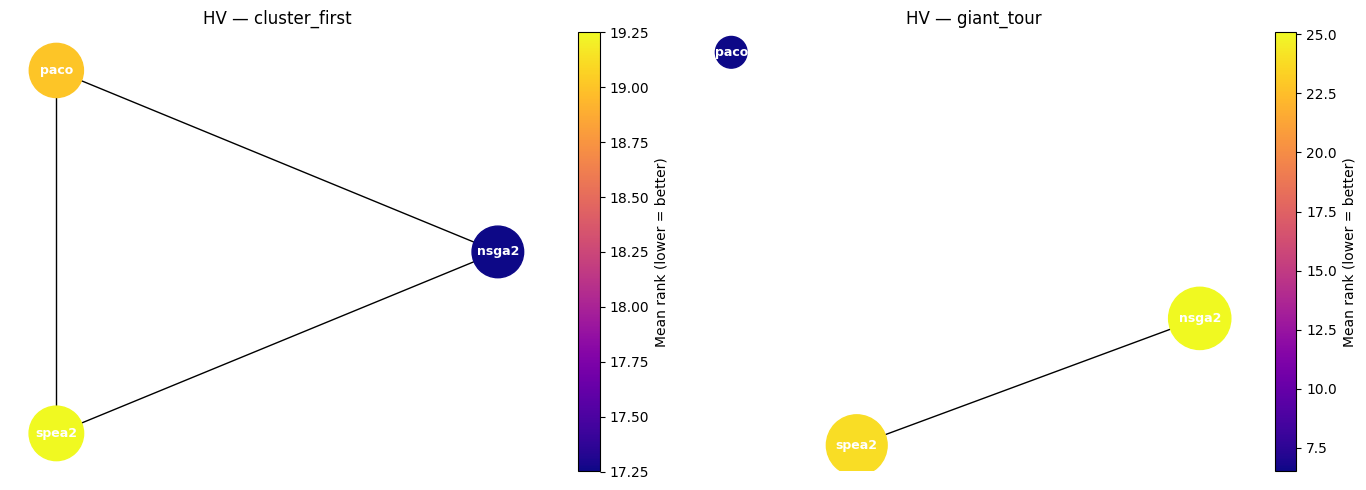

--- SP / cluster_first ---
  Friedman p=0.5442, significant=False
  Rankings: nsga2=18.46, paco=21.33, spea2=15.71
--- SP / giant_tour ---
  Friedman p=0.0012, significant=True
  Rankings: nsga2=19.67, paco=27.17, spea2=8.67
  Significant pairs: paco vs spea2, nsga2 vs spea2


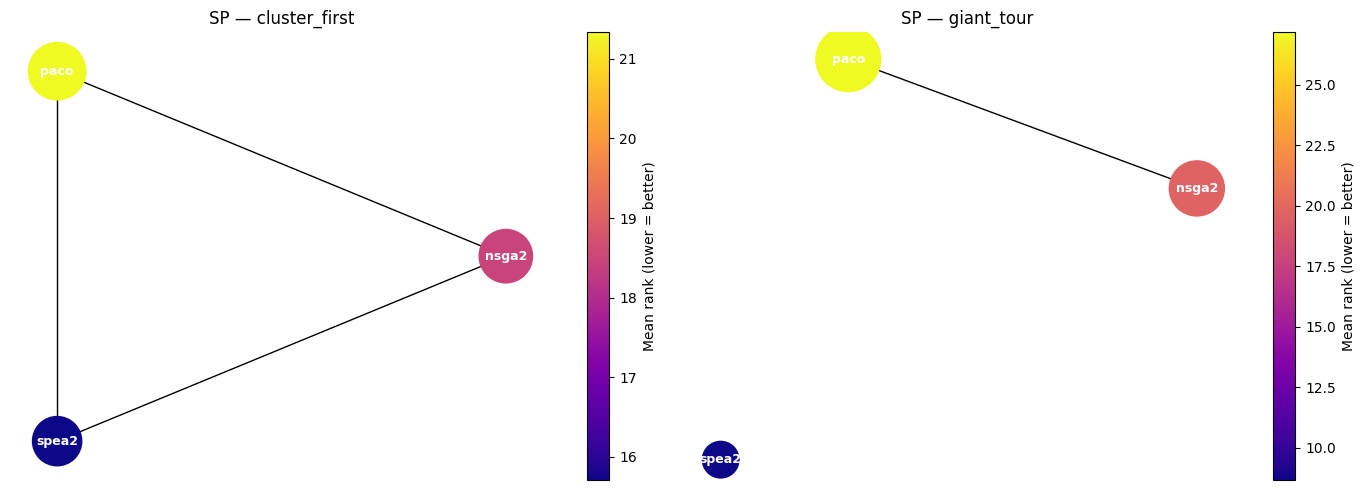

--- GD / cluster_first ---
  Friedman p=0.7026, significant=False
  Rankings: nsga2=16.25, paco=18.75, spea2=20.50
--- GD / giant_tour ---
  Friedman p=0.0005, significant=True
  Rankings: nsga2=26.00, paco=7.33, spea2=22.17
  Significant pairs: nsga2 vs paco, paco vs spea2


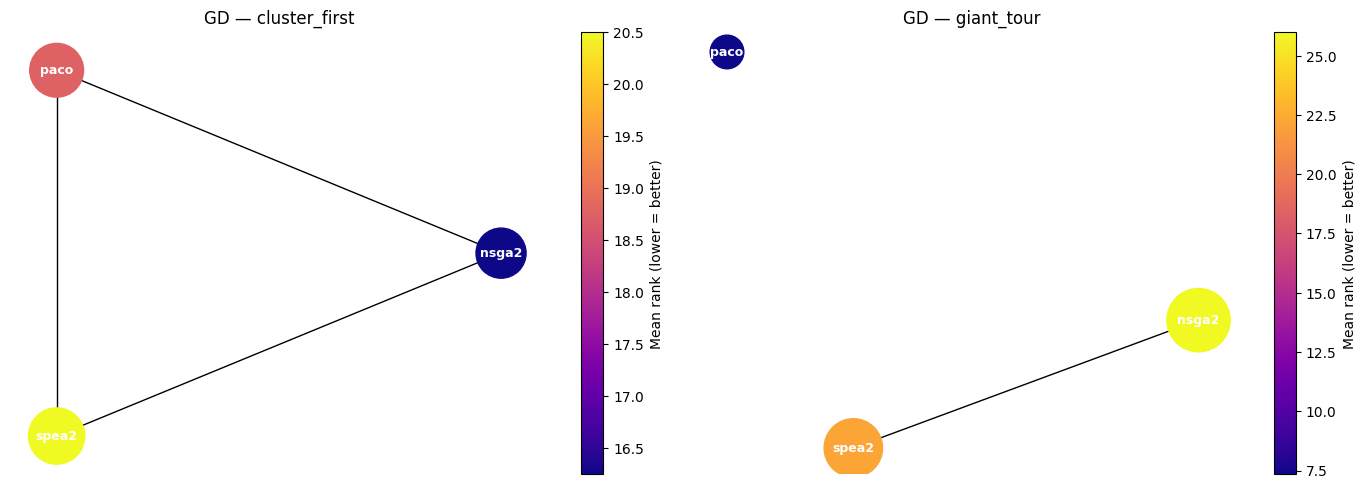

--- PF / cluster_first ---
  Friedman p=0.0012, significant=True
  Rankings: nsga2=23.46, paco=8.08, spea2=23.96
  Significant pairs: paco vs spea2, nsga2 vs paco
--- PF / giant_tour ---
  Friedman p=0.0002, significant=True
  Rankings: nsga2=10.71, paco=30.50, spea2=14.29
  Significant pairs: nsga2 vs paco, paco vs spea2


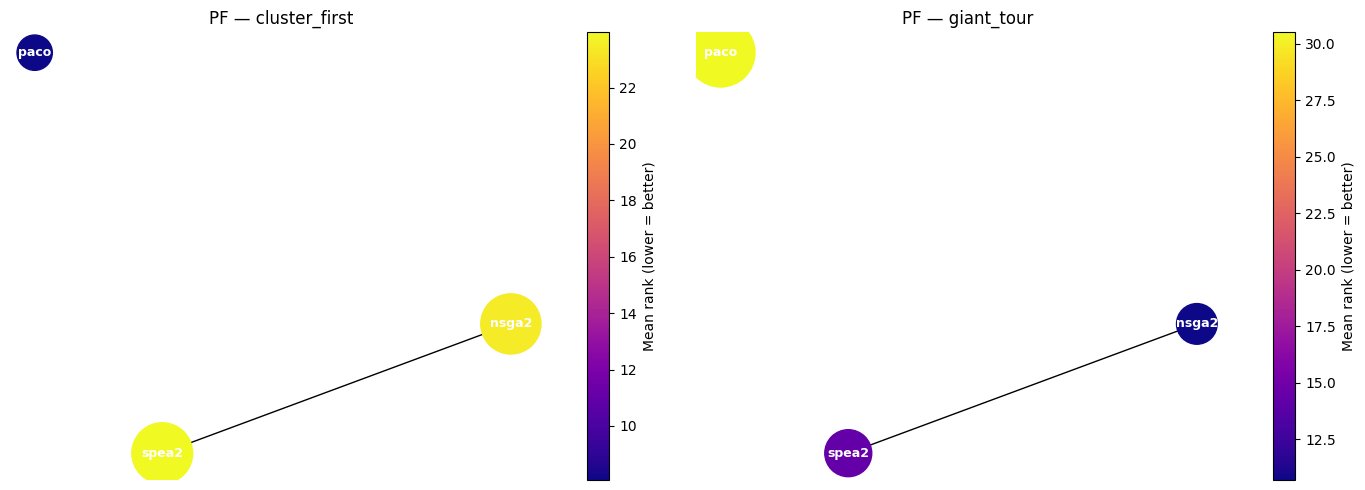

In [15]:
for metric in ["hv", "sp", "gd", "pf"]:
    fig, axes = plt.subplots(1, len(representations), figsize=(14, 5))
    for ax, rep in zip(axes, representations):
        groups = {}
        for algo in algorithms:
            medians_per_instance = [
                float(np.median(loader.compute_metric_series(algo, rep, inst, metric)))
                for inst in instances
            ]
            groups[algo] = medians_per_instance

        result = friedman_shaffer_test(
            groups, alpha=ALPHA, maximize=MAXIMIZE[metric],
        )

        plot_critical_difference(
            result["rankings"],
            result["post_hoc"],
            ax=ax,
            title=f"{metric.upper()} — {rep}",
        )

        print(f"--- {metric.upper()} / {rep} ---")
        print(f"  Friedman p={result['friedman_p_value']:.4f}, "
              f"significant={result['friedman_significant']}")
        print(f"  Rankings: " + ", ".join(
            f"{a}={r:.2f}" for a, r in result["rankings"].items()
        ))
        if result["post_hoc"]:
            sig = [ph["comparison"] for ph in result["post_hoc"] if ph["significant"]]
            if sig:
                print(f"  Significant pairs: {', '.join(sig)}")
    fig.tight_layout()
    plt.show()

## 9. Parameter heatmaps

Heatmaps of mean HV across two hyperparameters from the grid search, with remaining parameters aggregated by `max` (best HV achievable at each cell). Justifies the chosen hyperparameter combination per algorithm by visualizing the grid search landscape.

- NSGA-II / SPEA2: `pop_size` × `mutation_rate`
- PACO: `alpha1` × `alpha2`

Grid search was performed on a single representative instance (X-n101-k25), following the standard single-instance tuning pattern used in BAO benchmarks.

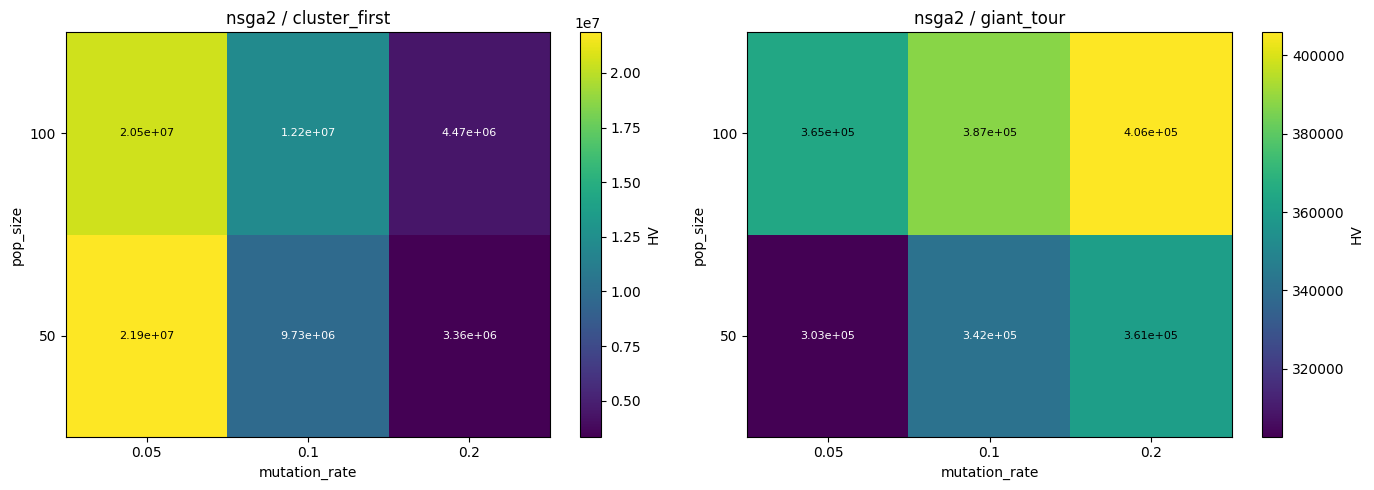

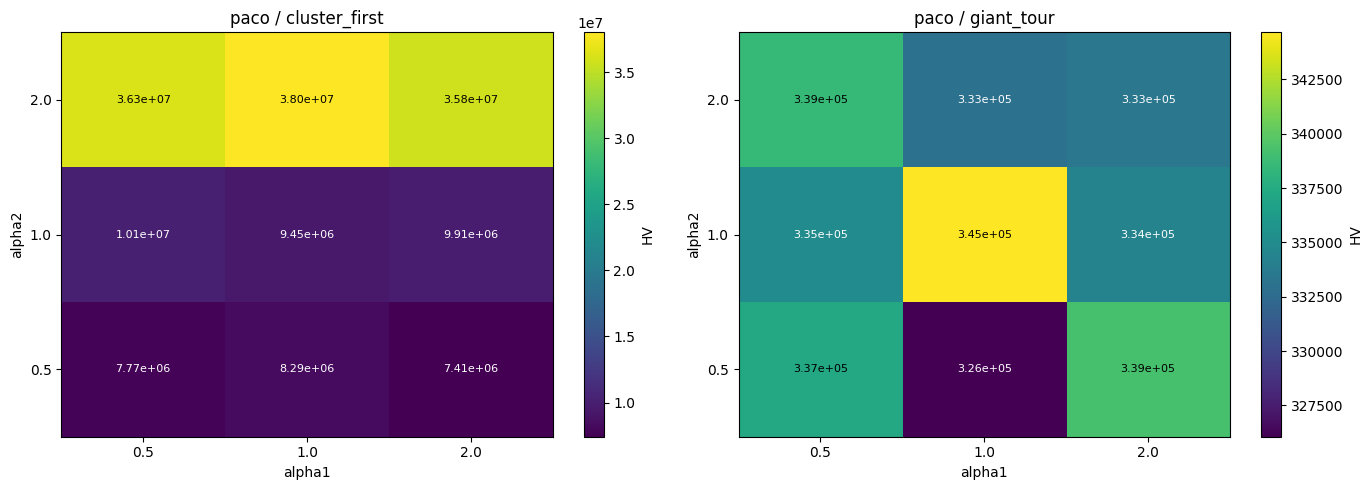

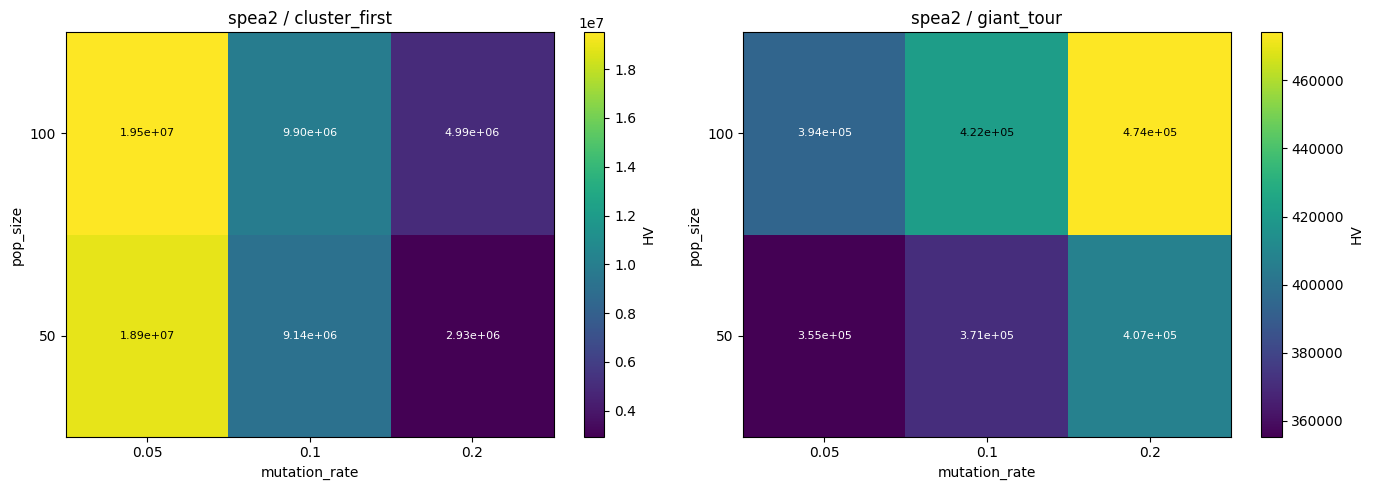

In [16]:
HEATMAP_PARAMS = {
    "nsga2": ("mutation_rate", "pop_size"),
    "spea2": ("mutation_rate", "pop_size"),
    "paco":  ("alpha1", "alpha2"),
}

for algo in algorithms:
    param_x, param_y = HEATMAP_PARAMS[algo]
    fig, axes = plt.subplots(1, len(representations), figsize=(14, 5))
    for ax, rep in zip(axes, representations):
        combos = grid_results[algo][rep]["all_combos"]
        plot_parameter_heatmap(
            combos, param_x=param_x, param_y=param_y, aggregate="max", ax=ax,
            title=f"{algo} / {rep}",
        )
    fig.tight_layout()
    plt.show()